In [41]:
import os
import yaml
import pandas as pd
import matplotlib.pyplot as plt
import time
import seaborn as sns  # optional, just for color if you like
import matplotlib.pyplot as plt
from scipy.stats import spearmanr
from sklearn.linear_model import LinearRegression
import numpy as np
import matplotlib.patches as mpatches
from matplotlib.lines import Line2D
import statsmodels.formula.api as smf
import math

In [42]:
base_dir = "/Users/seohyon/resources/results"

# will track only these methods (above BBKNN)
keep_methods = [
    "embed_cell_types_jittered",
    "embed_cell_types",
    "shuffle_integration",
    "shuffle_integration_by_cell_type",
    "shuffle_integration",
    "scanvi",
    "combat",
    "scvi",
    "harmony",
    "harmonypy",
    "batchelor_fastmnn",
    "liger",
    "pyliger",
    "scalex",
    "uce",
    "no_integration",
    "no_integration_batch",
    "scanorama"
]

yaml_path = "/Users/seohyon/resources/results/run_2025-10-11_13-28-50/score_uns.yaml"
rows = []

with open(yaml_path, "r") as f:
    data = yaml.safe_load(f)

for entry in data:
    method = entry.get("method_id", "").strip().lower()

    # keep only desired methods
    if method not in keep_methods:
        continue

    metrics = entry.get("metric_ids", [])
    values = entry.get("metric_values", [])

    for m_id, m_val in zip(metrics, values):
        rows.append({
            "dataset_id": entry.get("dataset_id"),
            "method_id": method,
            "metric_id": m_id,
            "metric_value": m_val
        })

In [43]:
df = pd.DataFrame(rows)
df = df.dropna(subset=["metric_value"]).copy() # drop NaN
# df = df[df["metric_id"] != "kbet"].copy() # drop kbet
df = df[~df["metric_id"].isin(["kbet", "hvg_overlap"])].copy() # drop unwanted metrics
df["dataset_id"] = df["dataset_id"].str.split("/").str[-1] # clean the dataset id

In [44]:
meta = pd.read_csv("/Users/seohyon/resources/Batch_Integration_Dataset - Copy of Tabellenblatt3.csv")

df = pd.merge(df, meta, left_on="dataset_id", right_on="dataset", how="inner").drop(columns=["dataset"])

control_type_map = {
    "embed_cell_types": "positive",
    "embed_cell_types_jittered": "positive",
    "shuffle_integration": "negative",
    "shuffle_integration_by_batch": "negative",
    "shuffle_integration_by_cell_type": "negative",
    "no_integration": "baseline",
    "no_integration_batch": "baseline",
}

df["control_type"] = df["method_id"].map(control_type_map).fillna("non-control")
df["control_group"] = df["control_type"].apply(
    lambda x: "non-control method" if x == "non-control" else "control method"
)

# mapping categorical to binary for plotting
df["nested_batches_num"] = df["nested_batches"].map({"No": 0, "Yes": 1})

bio_metrics = [
    'ari',
    'nmi',
    'graph_connectivity',
    'cell_cycle_conservation',
    'asw_label',
    'isolated_label_f1',
    'isolated_label_asw',
]

batch_metrics = [
    'pcr',
    'ilisi',
    'clisi',
    'asw_batch',
    'kbet_pg',
    'kbet_pg_label',
    'ari_batch',
    'nmi_batch',
]

def categorize_metric(m):
    if m in bio_metrics:
        return "bio"
    if m in batch_metrics:
        return "batch"
    return "baseline"

df["metric_type"] = df["metric_id"].apply(categorize_metric)

In [45]:
baseline = df[df["metric_type"] == "baseline"]
non_baseline = df[df["metric_type"] != "baseline"]

# For non-baseline, the metric_group is just metric_type ("bio" or "batch")
non_baseline = non_baseline.assign(metric_group=non_baseline["metric_type"])

# Duplicate baseline rows: one copy for "bio", one for "batch"
baseline_bio = baseline.copy()
baseline_bio["metric_group"] = "bio"

baseline_batch = baseline.copy()
baseline_batch["metric_group"] = "batch"

# Combine everything
df = pd.concat(
    [non_baseline, baseline_bio, baseline_batch],
    ignore_index=True
)

# with ARI

In [46]:
rows = []

for method, df_m in df.query("metric_id == 'ari' and control_group == 'non-control method'").groupby("method_id"):
    # skip methods with too few points or no variation
    if df_m["nested_batches_num"].nunique() < 2 or len(df_m) < 4:
        continue

    res = smf.ols("metric_value ~ nested_batches_num", data=df_m).fit()

    rows.append({
        "method_id": method,
        "n": len(df_m),
        "slope": res.params["nested_batches_num"],
        "pval": res.pvalues["nested_batches_num"],
        "r2": res.rsquared,
    })

results = pd.DataFrame(rows)
print(results)

            method_id  n     slope      pval        r2
0   batchelor_fastmnn  6  0.051916  0.678310  0.047484
1              combat  6  0.057874  0.746505  0.029122
2             harmony  6  0.163440  0.321622  0.242000
3           harmonypy  6  0.092710  0.501774  0.119683
4               liger  6  0.110045  0.520786  0.109981
5             pyliger  6  0.099529  0.458844  0.143568
6              scalex  6 -0.044643  0.587236  0.079923
7           scanorama  6 -0.077683  0.324254  0.239731
8              scanvi  6  0.353906  0.089455  0.554560
9                scvi  6  0.264649  0.176602  0.401699
10                uce  6  0.119894  0.141363  0.455477


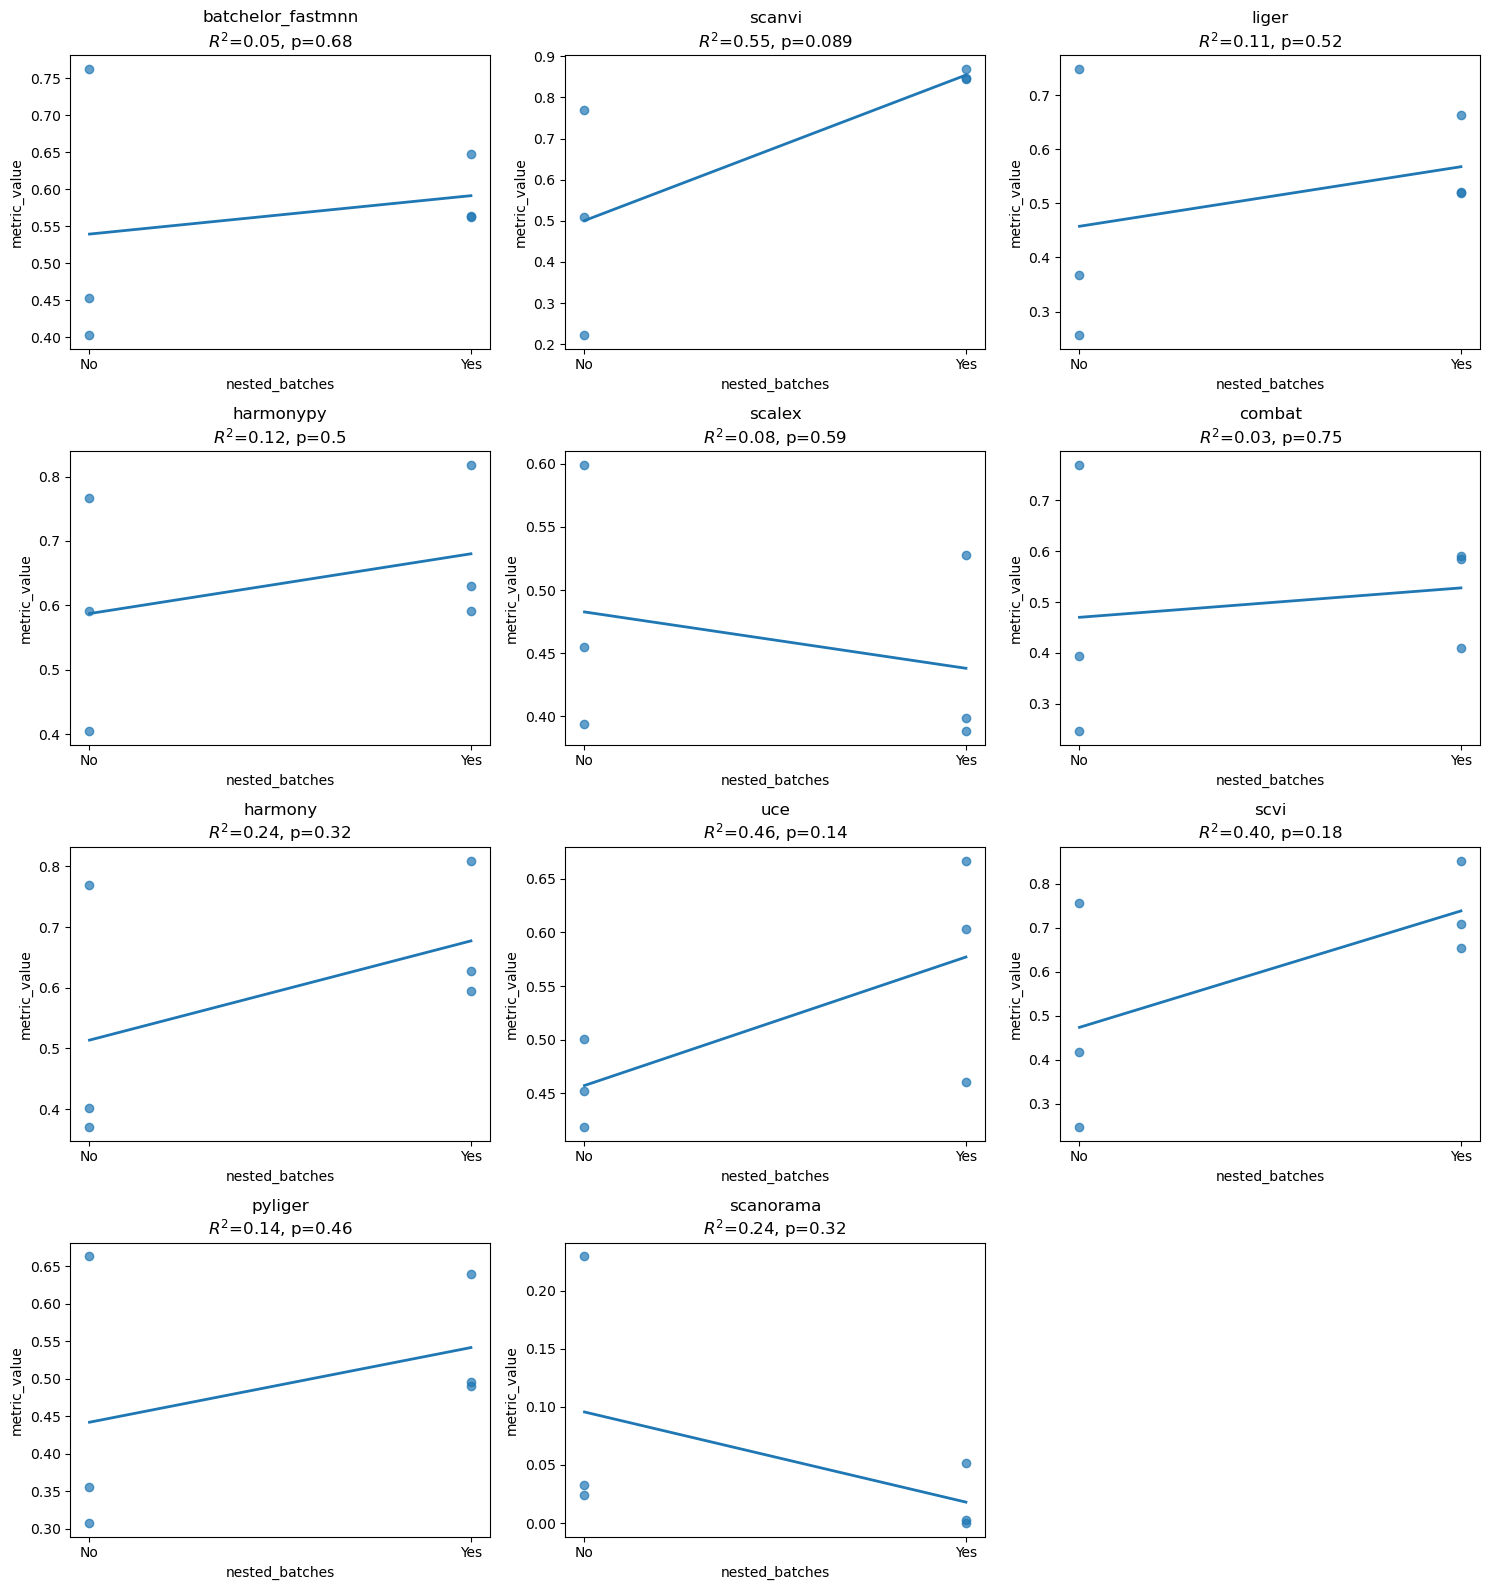

In [48]:
df_metric = df.query("metric_id == 'ari'") 

methods = df.query("control_group == 'non-control method'")["method_id"].unique()

n_methods = len(methods)
ncols = 3                      # change this if you want 2 per row, etc.
nrows = math.ceil(n_methods / ncols)

fig, axes = plt.subplots(nrows, ncols,
                         figsize=(5 * ncols, 4 * nrows),
                         squeeze=False)
axes = axes.ravel()

for ax, method in zip(axes, methods):
    df_m = df_metric.query("method_id == @method")

    res = smf.ols("metric_value ~ nested_batches_num", data=df_m).fit()

    # Scatter points
    x = df_m["nested_batches_num"]
    y = df_m["metric_value"]
    ax.scatter(x, y, alpha=0.7)

    # Regression line
    x_pred = np.linspace(x.min(), x.max(), 100)
    X_pred = pd.DataFrame({"nested_batches_num": x_pred})
    y_pred = res.predict(X_pred)
    ax.plot(x_pred, y_pred, linewidth=2)

    # Labels & title with stats
    ax.set_xticks([0, 1])
    ax.set_xticklabels(["No", "Yes"])
    ax.set_xlabel("nested_batches")
    ax.set_ylabel("metric_value")
    ax.set_title(
        f"{method}\n$R^2$={res.rsquared:.2f}, "
        f"p={res.pvalues['nested_batches_num']:.2g}"
    )

# ------------------------------------------------------------------
# 5) Hide unused axes if grid is larger than number of methods
# ------------------------------------------------------------------
for j in range(n_methods, len(axes)):
    fig.delaxes(axes[j])

# fig.suptitle("metric_value ~ batch_imbalance_gc per method", y=1.02)
fig.tight_layout()
plt.show()

# with NMI

In [49]:
rows = []

for method, df_m in df.query("metric_id == 'nmi' and control_group == 'non-control method'").groupby("method_id"):
    # skip methods with too few points or no variation
    if df_m["nested_batches_num"].nunique() < 2 or len(df_m) < 4:
        continue

    res = smf.ols("metric_value ~ nested_batches_num", data=df_m).fit()

    rows.append({
        "method_id": method,
        "n": len(df_m),
        "slope": res.params["nested_batches_num"],
        "pval": res.pvalues["nested_batches_num"],
        "r2": res.rsquared,
    })

results = pd.DataFrame(rows)
print(results)

            method_id  n     slope      pval        r2
0   batchelor_fastmnn  6  0.026617  0.584433  0.081077
1              combat  6  0.023268  0.754343  0.027316
2             harmony  6  0.018229  0.746146  0.029207
3           harmonypy  6  0.016090  0.733796  0.032182
4               liger  6 -0.040917  0.514633  0.113065
5             pyliger  6 -0.035234  0.447730  0.150225
6              scalex  6 -0.079098  0.036036  0.706805
7           scanorama  6 -0.102523  0.270213  0.290098
8              scanvi  6  0.127616  0.198892  0.371580
9                scvi  6  0.089399  0.274699  0.285592
10                uce  6  0.040744  0.280082  0.280269


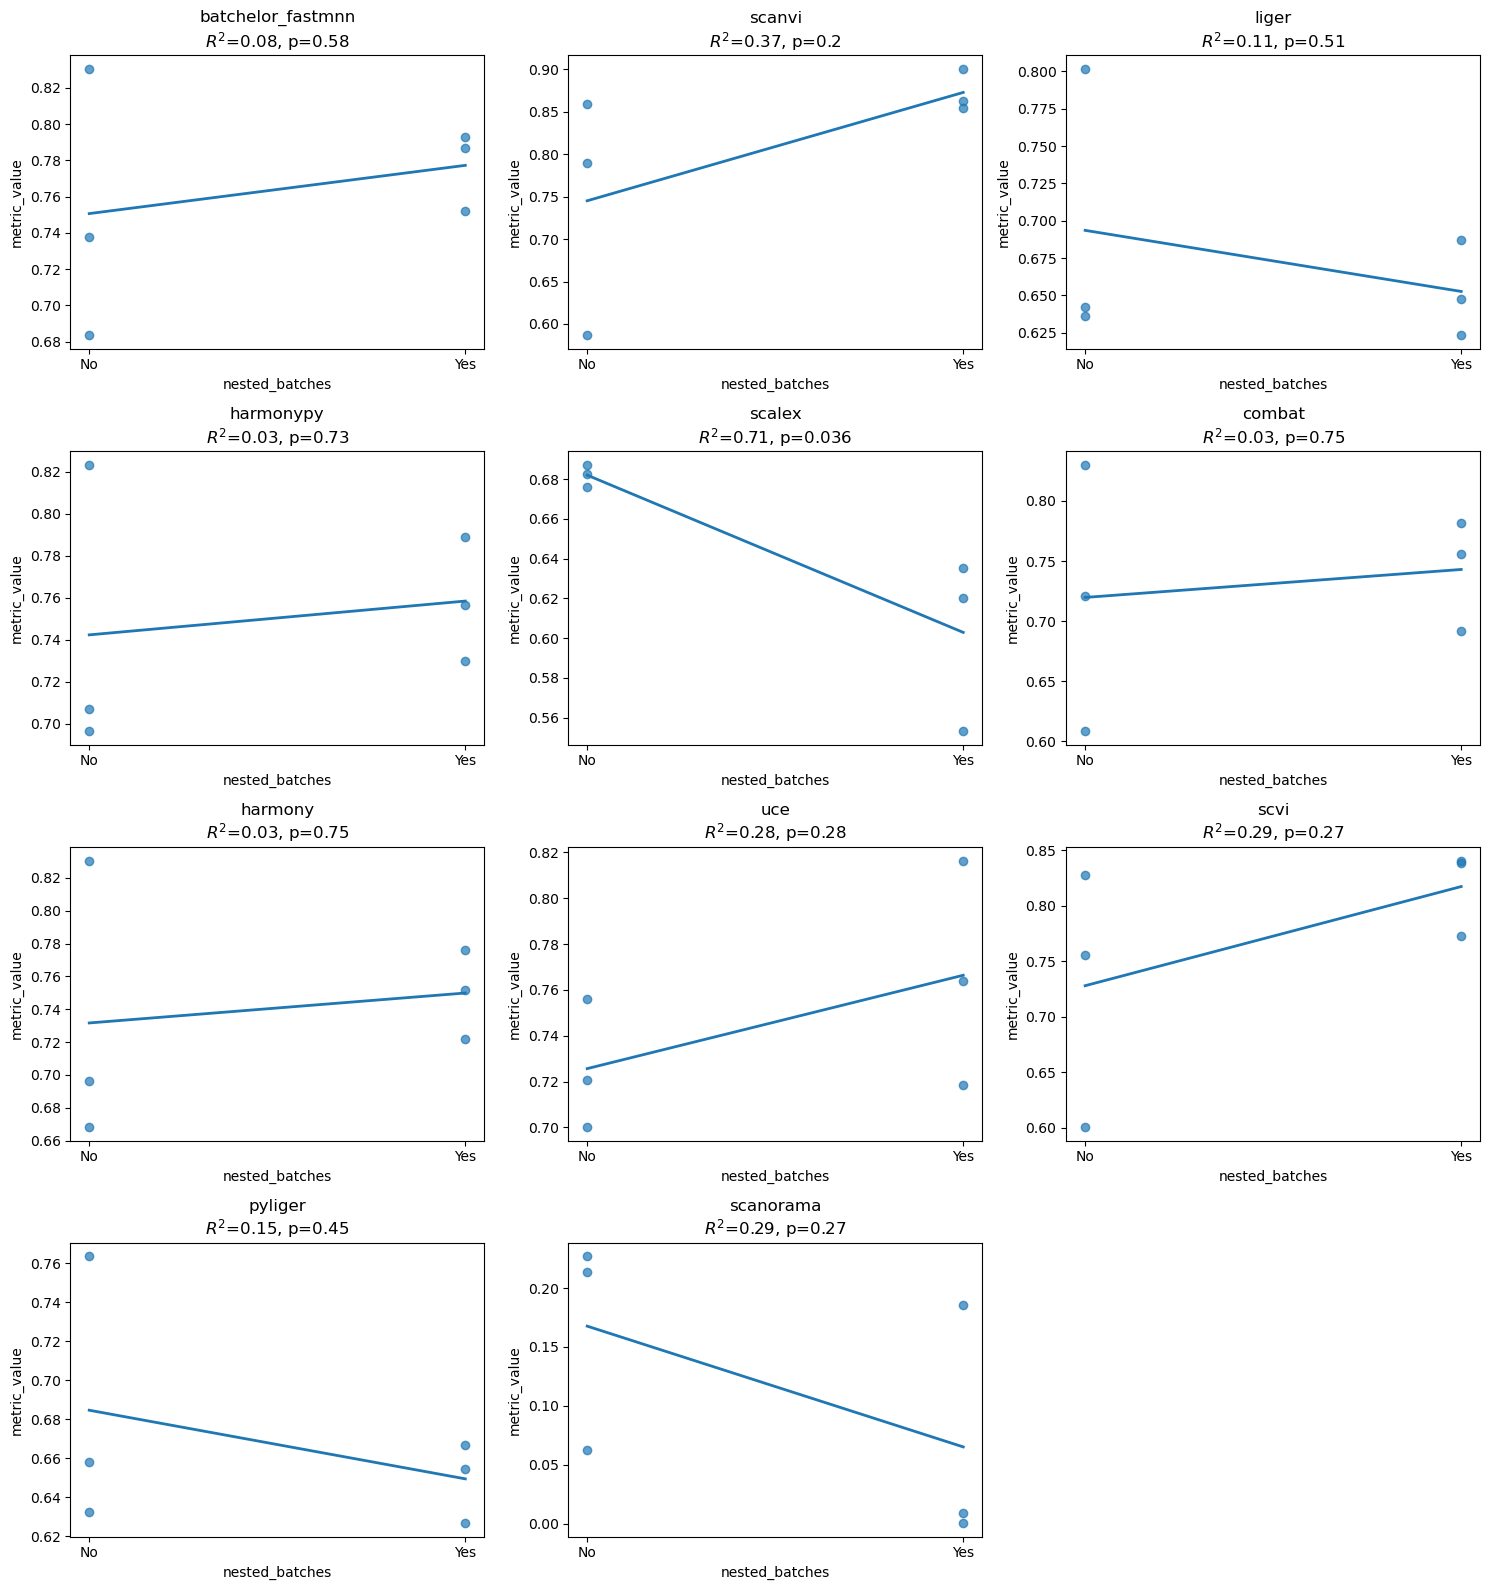

In [50]:
df_metric = df.query("metric_id == 'nmi'") 

methods = df.query("control_group == 'non-control method'")["method_id"].unique()

n_methods = len(methods)
ncols = 3                      # change this if you want 2 per row, etc.
nrows = math.ceil(n_methods / ncols)

fig, axes = plt.subplots(nrows, ncols,
                         figsize=(5 * ncols, 4 * nrows),
                         squeeze=False)
axes = axes.ravel()

for ax, method in zip(axes, methods):
    df_m = df_metric.query("method_id == @method")

    res = smf.ols("metric_value ~ nested_batches_num", data=df_m).fit()

    # Scatter points
    x = df_m["nested_batches_num"]
    y = df_m["metric_value"]
    ax.scatter(x, y, alpha=0.7)

    # Regression line
    x_pred = np.linspace(x.min(), x.max(), 100)
    X_pred = pd.DataFrame({"nested_batches_num": x_pred})
    y_pred = res.predict(X_pred)
    ax.plot(x_pred, y_pred, linewidth=2)

    # Labels & title with stats
    ax.set_xticks([0, 1])
    ax.set_xticklabels(["No", "Yes"])
    ax.set_xlabel("nested_batches")
    ax.set_ylabel("metric_value")
    ax.set_title(
        f"{method}\n$R^2$={res.rsquared:.2f}, "
        f"p={res.pvalues['nested_batches_num']:.2g}"
    )

# ------------------------------------------------------------------
# 5) Hide unused axes if grid is larger than number of methods
# ------------------------------------------------------------------
for j in range(n_methods, len(axes)):
    fig.delaxes(axes[j])

# fig.suptitle("metric_value ~ batch_imbalance_gc per method", y=1.02)
fig.tight_layout()
plt.show()

# with graph_connectivity

In [51]:
rows = []

for method, df_m in df.query("metric_id == 'graph_connectivity' and control_group == 'non-control method'").groupby("method_id"):
    # skip methods with too few points or no variation
    if df_m["nested_batches_num"].nunique() < 2 or len(df_m) < 4:
        continue

    res = smf.ols("metric_value ~ nested_batches_num", data=df_m).fit()

    rows.append({
        "method_id": method,
        "n": len(df_m),
        "slope": res.params["nested_batches_num"],
        "pval": res.pvalues["nested_batches_num"],
        "r2": res.rsquared,
    })

results = pd.DataFrame(rows)
print(results)

            method_id  n     slope      pval            r2
0   batchelor_fastmnn  6  0.050573  0.397213  1.831757e-01
1              combat  6  0.033813  0.322585  2.411673e-01
2             harmony  6  0.013201  0.788989  2.005646e-02
3           harmonypy  6  0.016484  0.749809  2.835358e-02
4               liger  6 -0.005743  0.971846  3.523698e-04
5             pyliger  6 -0.000140  0.999349  1.885537e-07
6              scalex  6  0.024263  0.783956  2.103843e-02
7           scanorama  6 -0.121264  0.374602  1.994780e-01
8              scanvi  6  0.043490  0.152404  4.377025e-01
9                scvi  6  0.051152  0.149707  4.419598e-01
10                uce  6  0.047890  0.084088  5.667571e-01


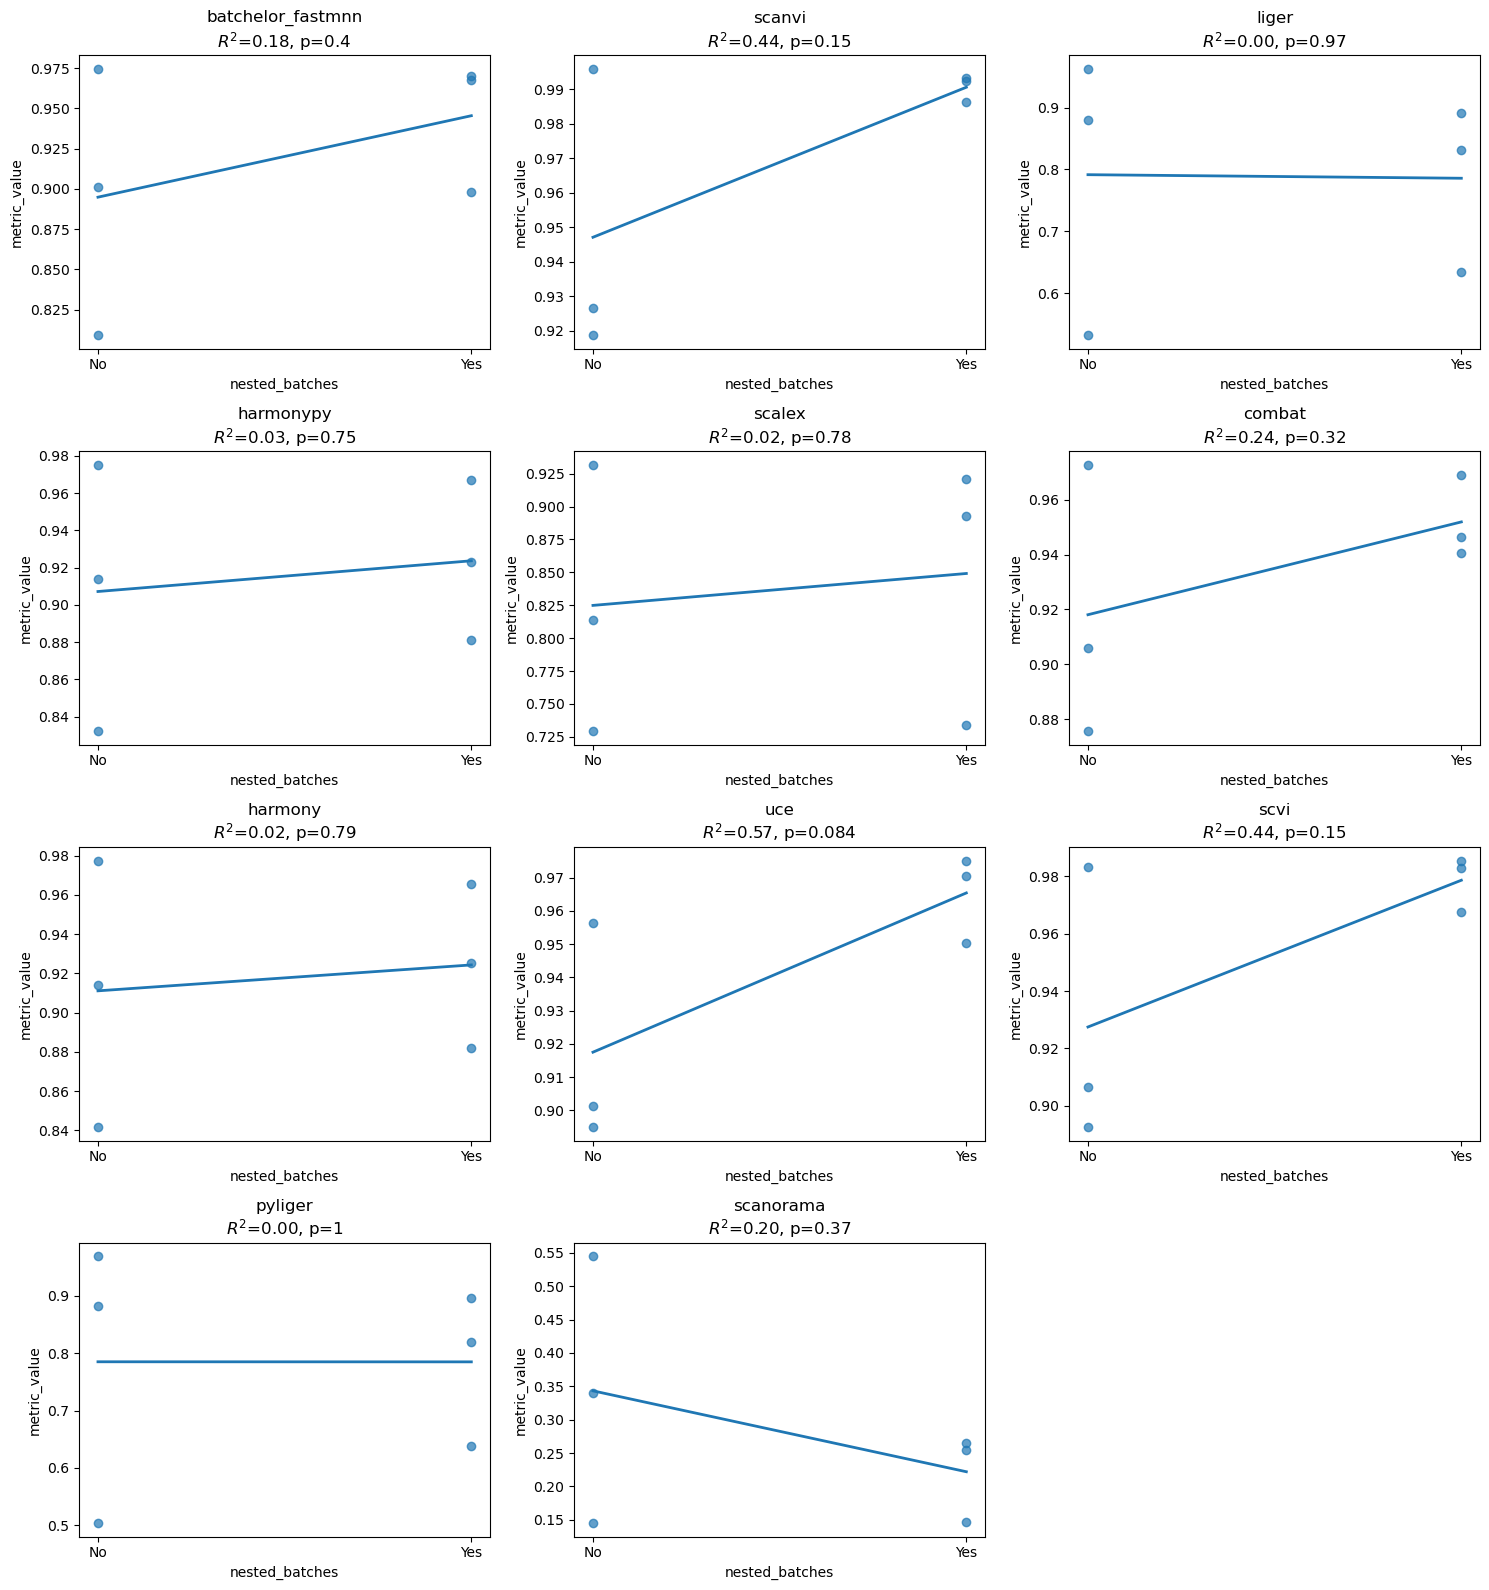

In [52]:
df_metric = df.query("metric_id == 'graph_connectivity'") 

methods = df.query("control_group == 'non-control method'")["method_id"].unique()

n_methods = len(methods)
ncols = 3                      # change this if you want 2 per row, etc.
nrows = math.ceil(n_methods / ncols)

fig, axes = plt.subplots(nrows, ncols,
                         figsize=(5 * ncols, 4 * nrows),
                         squeeze=False)
axes = axes.ravel()

for ax, method in zip(axes, methods):
    df_m = df_metric.query("method_id == @method")

    res = smf.ols("metric_value ~ nested_batches_num", data=df_m).fit()

    # Scatter points
    x = df_m["nested_batches_num"]
    y = df_m["metric_value"]
    ax.scatter(x, y, alpha=0.7)

    # Regression line
    x_pred = np.linspace(x.min(), x.max(), 100)
    X_pred = pd.DataFrame({"nested_batches_num": x_pred})
    y_pred = res.predict(X_pred)
    ax.plot(x_pred, y_pred, linewidth=2)

    # Labels & title with stats
    ax.set_xticks([0, 1])
    ax.set_xticklabels(["No", "Yes"])
    ax.set_xlabel("nested_batches")
    ax.set_ylabel("metric_value")
    ax.set_title(
        f"{method}\n$R^2$={res.rsquared:.2f}, "
        f"p={res.pvalues['nested_batches_num']:.2g}"
    )

# ------------------------------------------------------------------
# 5) Hide unused axes if grid is larger than number of methods
# ------------------------------------------------------------------
for j in range(n_methods, len(axes)):
    fig.delaxes(axes[j])

# fig.suptitle("metric_value ~ batch_imbalance_gc per method", y=1.02)
fig.tight_layout()
plt.show()

# with cell_cycle_conservation

In [53]:
rows = []

for method, df_m in df.query("metric_id == 'cell_cycle_conservation' and control_group == 'non-control method'").groupby("method_id"):
    # skip methods with too few points or no variation
    if df_m["nested_batches_num"].nunique() < 2 or len(df_m) < 4:
        continue

    res = smf.ols("metric_value ~ nested_batches_num", data=df_m).fit()

    rows.append({
        "method_id": method,
        "n": len(df_m),
        "slope": res.params["nested_batches_num"],
        "pval": res.pvalues["nested_batches_num"],
        "r2": res.rsquared,
    })

results = pd.DataFrame(rows)
print(results)

            method_id  n     slope      pval        r2
0   batchelor_fastmnn  6 -0.010078  0.894559  0.004958
1              combat  6  0.005241  0.887129  0.005684
2             harmony  6  0.027296  0.716768  0.036538
3           harmonypy  6  0.021567  0.773317  0.023195
4               liger  6 -0.059503  0.115113  0.501897
5             pyliger  6  0.104010  0.316778  0.246221
6              scalex  6  0.139973  0.197548  0.373323
7           scanorama  6 -0.140173  0.229063  0.334649
8              scanvi  6  0.103990  0.143198  0.452458
9                scvi  6  0.038577  0.675676  0.048292
10                uce  6 -0.116857  0.234900  0.327950


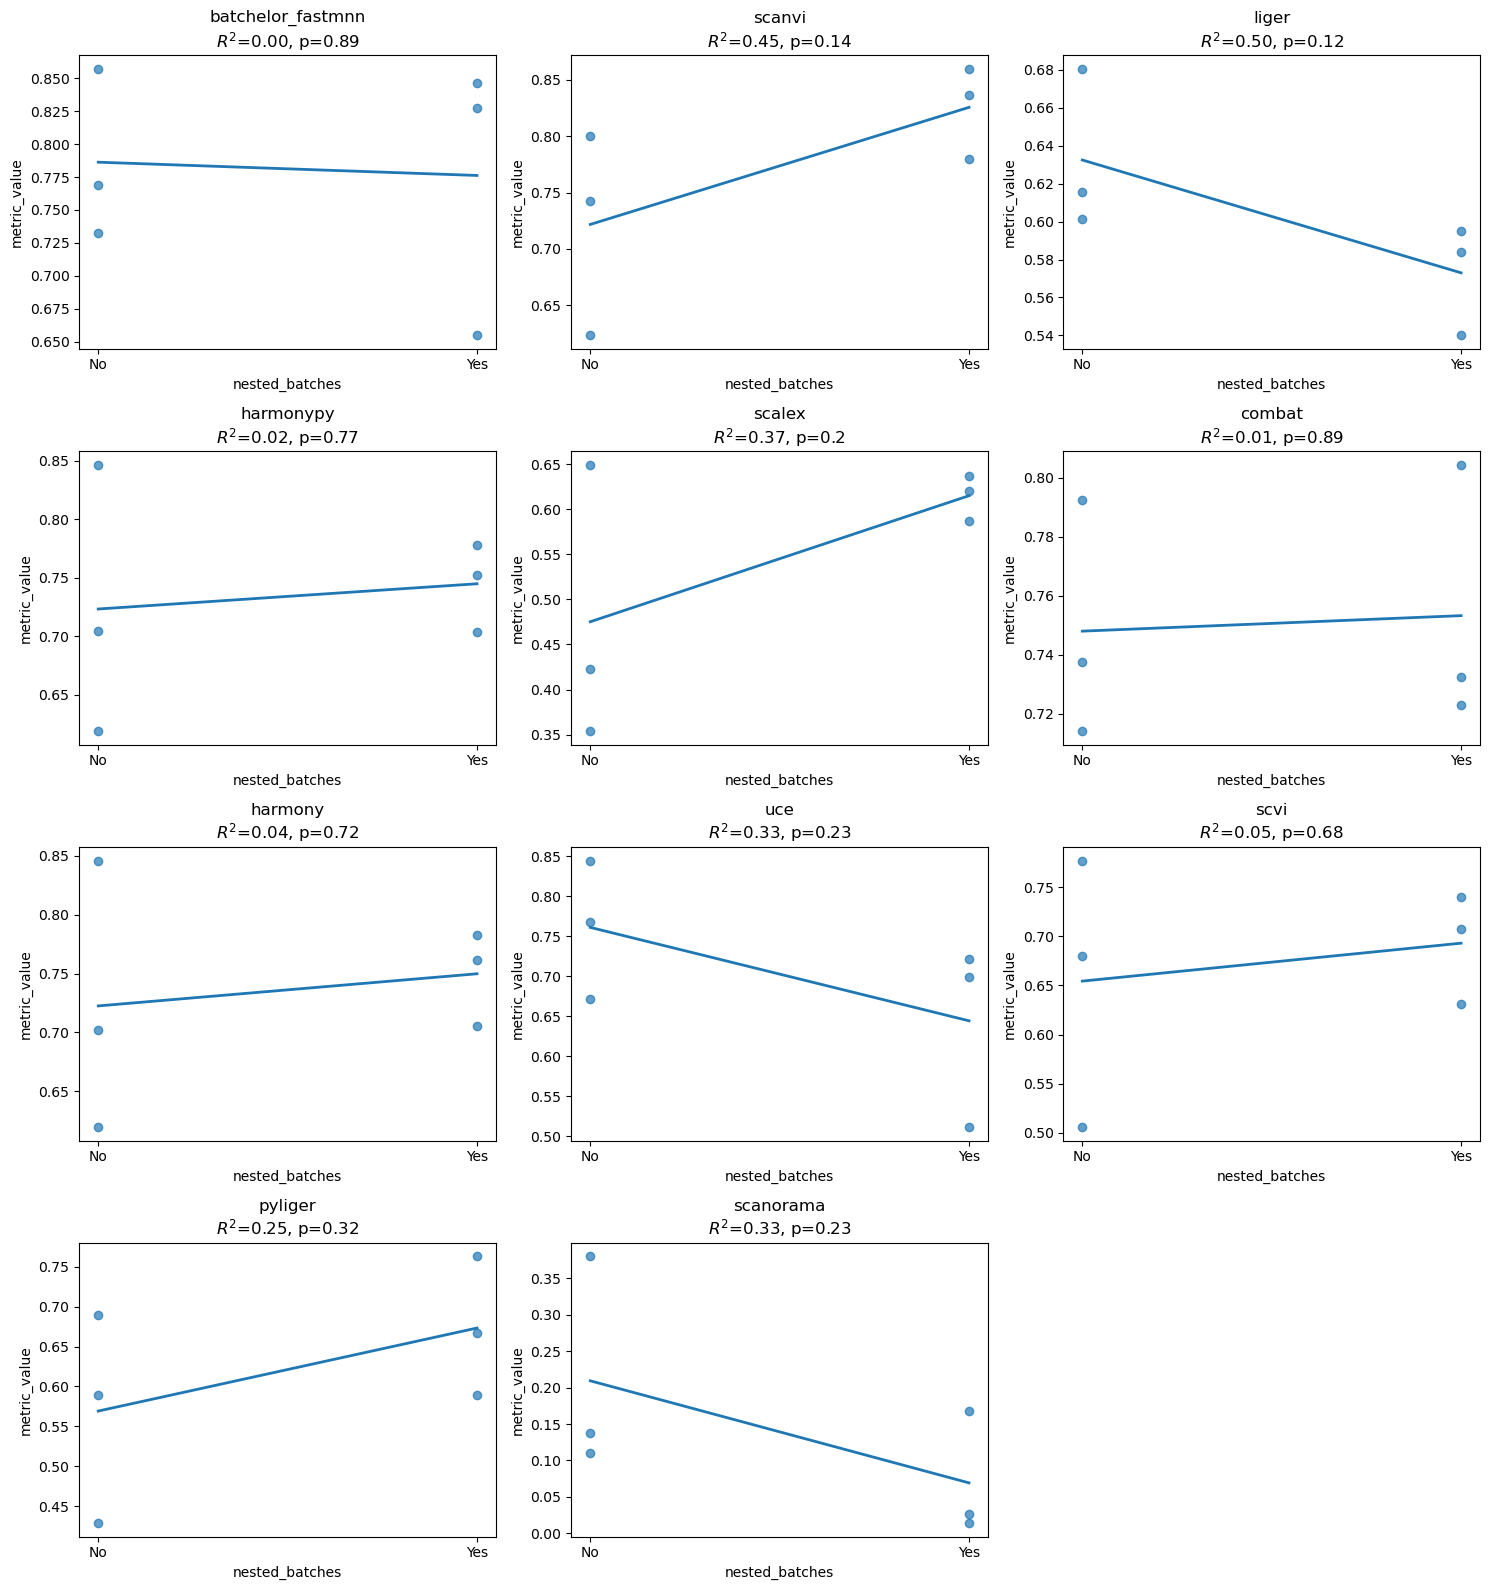

In [54]:
df_metric = df.query("metric_id == 'cell_cycle_conservation'") 

methods = df.query("control_group == 'non-control method'")["method_id"].unique()

n_methods = len(methods)
ncols = 3                      # change this if you want 2 per row, etc.
nrows = math.ceil(n_methods / ncols)

fig, axes = plt.subplots(nrows, ncols,
                         figsize=(5 * ncols, 4 * nrows),
                         squeeze=False)
axes = axes.ravel()

for ax, method in zip(axes, methods):
    df_m = df_metric.query("method_id == @method")

    res = smf.ols("metric_value ~ nested_batches_num", data=df_m).fit()

    # Scatter points
    x = df_m["nested_batches_num"]
    y = df_m["metric_value"]
    ax.scatter(x, y, alpha=0.7)

    # Regression line
    x_pred = np.linspace(x.min(), x.max(), 100)
    X_pred = pd.DataFrame({"nested_batches_num": x_pred})
    y_pred = res.predict(X_pred)
    ax.plot(x_pred, y_pred, linewidth=2)

    # Labels & title with stats
    ax.set_xticks([0, 1])
    ax.set_xticklabels(["No", "Yes"])
    ax.set_xlabel("nested_batches")
    ax.set_ylabel("metric_value")
    ax.set_title(
        f"{method}\n$R^2$={res.rsquared:.2f}, "
        f"p={res.pvalues['nested_batches_num']:.2g}"
    )

# ------------------------------------------------------------------
# 5) Hide unused axes if grid is larger than number of methods
# ------------------------------------------------------------------
for j in range(n_methods, len(axes)):
    fig.delaxes(axes[j])

# fig.suptitle("metric_value ~ batch_imbalance_gc per method", y=1.02)
fig.tight_layout()
plt.show()

# with asw_label

In [55]:
rows = []

for method, df_m in df.query("metric_id == 'asw_label' and control_group == 'non-control method'").groupby("method_id"):
    # skip methods with too few points or no variation
    if df_m["nested_batches_num"].nunique() < 2 or len(df_m) < 4:
        continue

    res = smf.ols("metric_value ~ nested_batches_num", data=df_m).fit()

    rows.append({
        "method_id": method,
        "n": len(df_m),
        "slope": res.params["nested_batches_num"],
        "pval": res.pvalues["nested_batches_num"],
        "r2": res.rsquared,
    })

results = pd.DataFrame(rows)
print(results)

            method_id  n     slope      pval        r2
0   batchelor_fastmnn  6 -0.028010  0.659686  0.053353
1              combat  6 -0.038862  0.422724  0.165965
2             harmony  6 -0.040408  0.576440  0.084419
3           harmonypy  6 -0.037400  0.599657  0.074929
4               liger  6 -0.044375  0.624219  0.065598
5             pyliger  6 -0.032705  0.724358  0.034560
6              scalex  6 -0.056934  0.353874  0.215355
7           scanorama  6  0.021226  0.680879  0.046704
8              scanvi  6  0.019038  0.587632  0.079761
9                scvi  6 -0.003878  0.859582  0.008815
10                uce  6 -0.026028  0.377859  0.197066


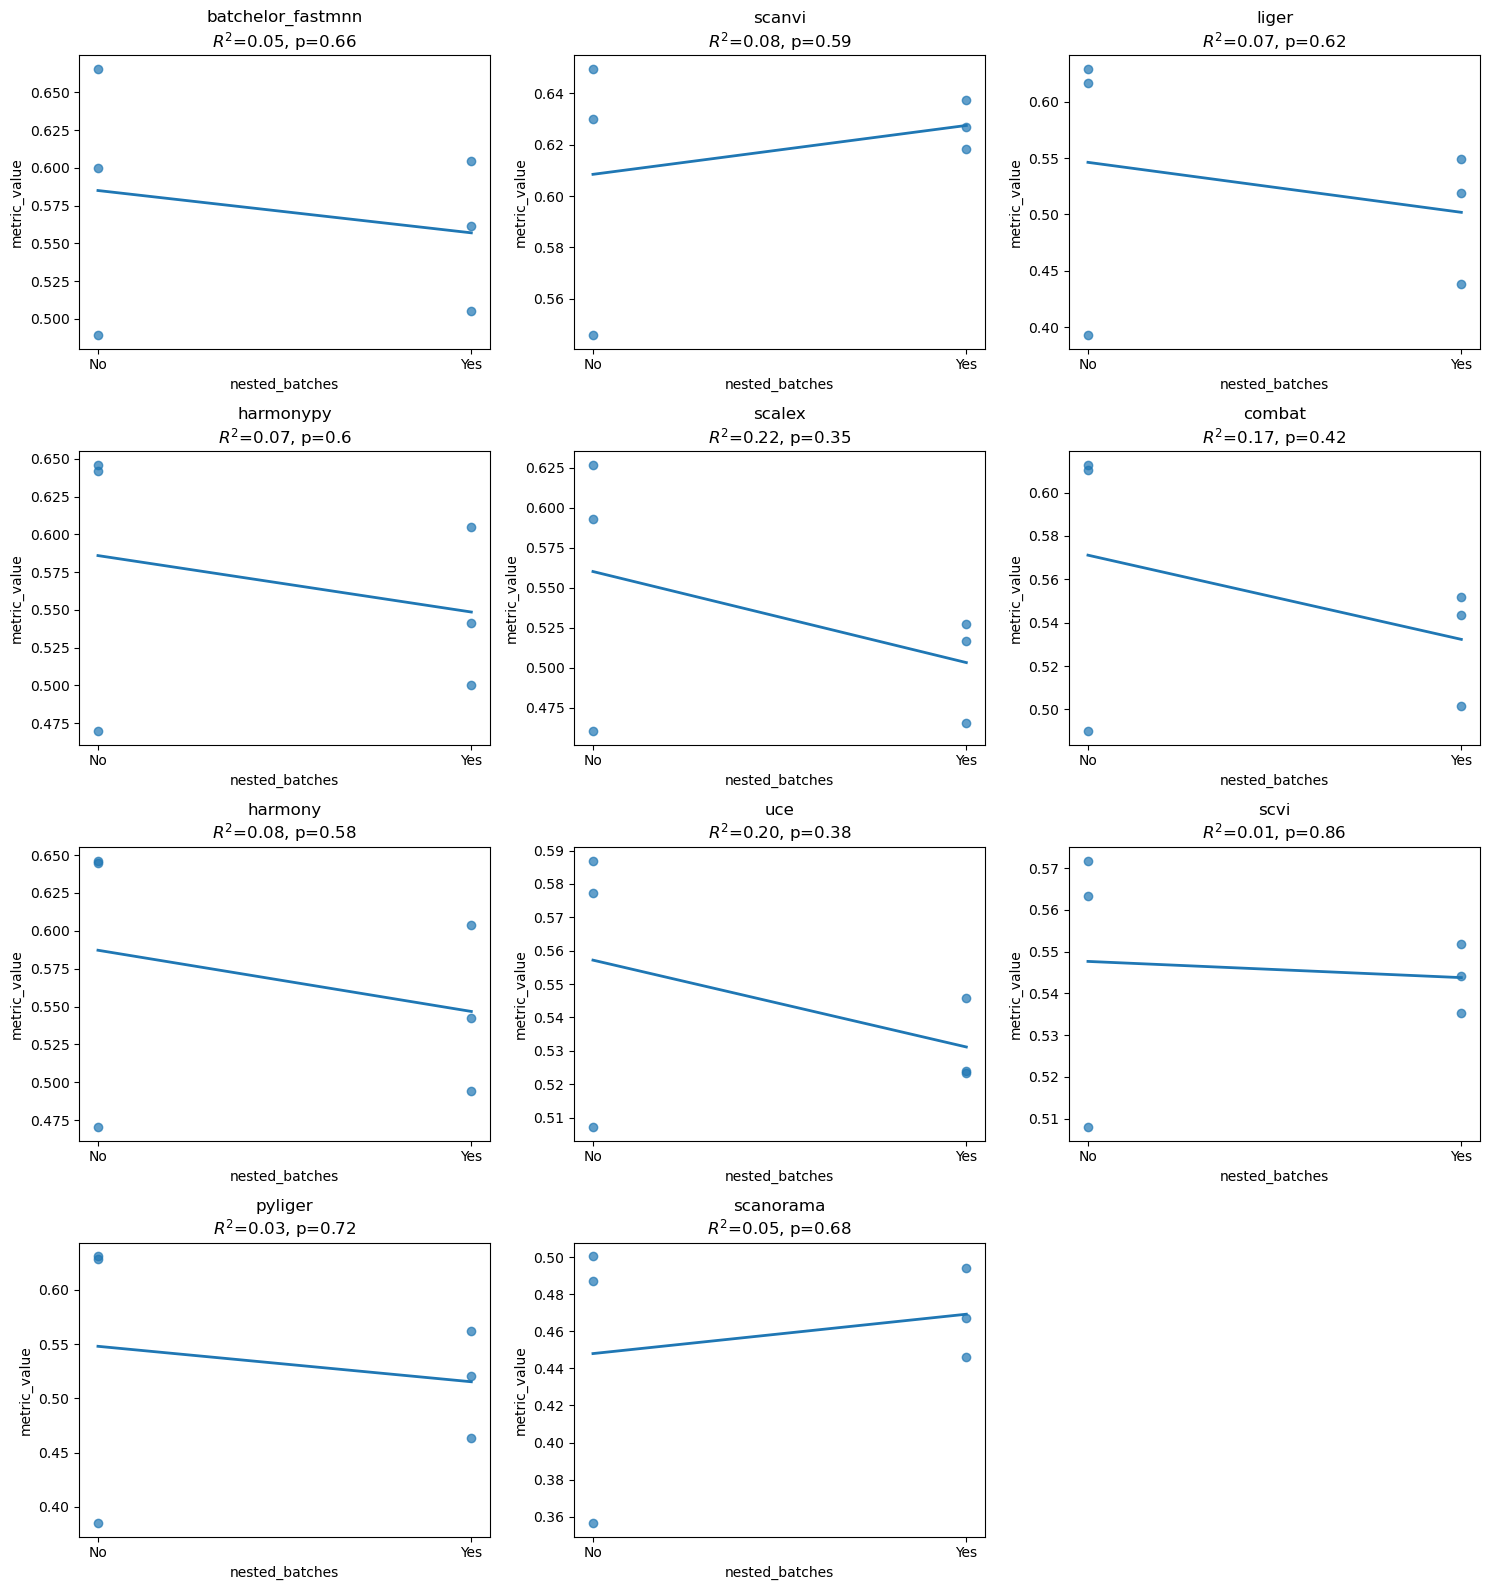

In [56]:
df_metric = df.query("metric_id == 'asw_label'") 

methods = df.query("control_group == 'non-control method'")["method_id"].unique()

n_methods = len(methods)
ncols = 3                      # change this if you want 2 per row, etc.
nrows = math.ceil(n_methods / ncols)

fig, axes = plt.subplots(nrows, ncols,
                         figsize=(5 * ncols, 4 * nrows),
                         squeeze=False)
axes = axes.ravel()

for ax, method in zip(axes, methods):
    df_m = df_metric.query("method_id == @method")

    res = smf.ols("metric_value ~ nested_batches_num", data=df_m).fit()

    # Scatter points
    x = df_m["nested_batches_num"]
    y = df_m["metric_value"]
    ax.scatter(x, y, alpha=0.7)

    # Regression line
    x_pred = np.linspace(x.min(), x.max(), 100)
    X_pred = pd.DataFrame({"nested_batches_num": x_pred})
    y_pred = res.predict(X_pred)
    ax.plot(x_pred, y_pred, linewidth=2)

    # Labels & title with stats
    ax.set_xticks([0, 1])
    ax.set_xticklabels(["No", "Yes"])
    ax.set_xlabel("nested_batches")
    ax.set_ylabel("metric_value")
    ax.set_title(
        f"{method}\n$R^2$={res.rsquared:.2f}, "
        f"p={res.pvalues['nested_batches_num']:.2g}"
    )

# ------------------------------------------------------------------
# 5) Hide unused axes if grid is larger than number of methods
# ------------------------------------------------------------------
for j in range(n_methods, len(axes)):
    fig.delaxes(axes[j])

# fig.suptitle("metric_value ~ batch_imbalance_gc per method", y=1.02)
fig.tight_layout()
plt.show()

# with isolated_label_f1

In [57]:
rows = []

for method, df_m in df.query("metric_id == 'isolated_label_f1' and control_group == 'non-control method'").groupby("method_id"):
    # skip methods with too few points or no variation
    if df_m["nested_batches_num"].nunique() < 2 or len(df_m) < 4:
        continue

    res = smf.ols("metric_value ~ nested_batches_num", data=df_m).fit()

    rows.append({
        "method_id": method,
        "n": len(df_m),
        "slope": res.params["nested_batches_num"],
        "pval": res.pvalues["nested_batches_num"],
        "r2": res.rsquared,
    })

results = pd.DataFrame(rows)
print(results)

            method_id  n     slope      pval        r2
0   batchelor_fastmnn  5  0.274717  0.505938  0.159106
1              combat  5  0.235304  0.472679  0.182814
2             harmony  5  0.005838  0.847175  0.014477
3           harmonypy  5  0.027812  0.468995  0.185564
4               liger  5  0.070473  0.118052  0.611635
5             pyliger  5  0.053713  0.227882  0.432261
6              scalex  5  0.011845  0.646646  0.079117
7           scanorama  5 -0.014699  0.368228  0.271233
8              scanvi  5  0.322815  0.463640  0.189605
9                scvi  5  0.301219  0.479194  0.178013
10                uce  5  0.011583  0.783420  0.029220


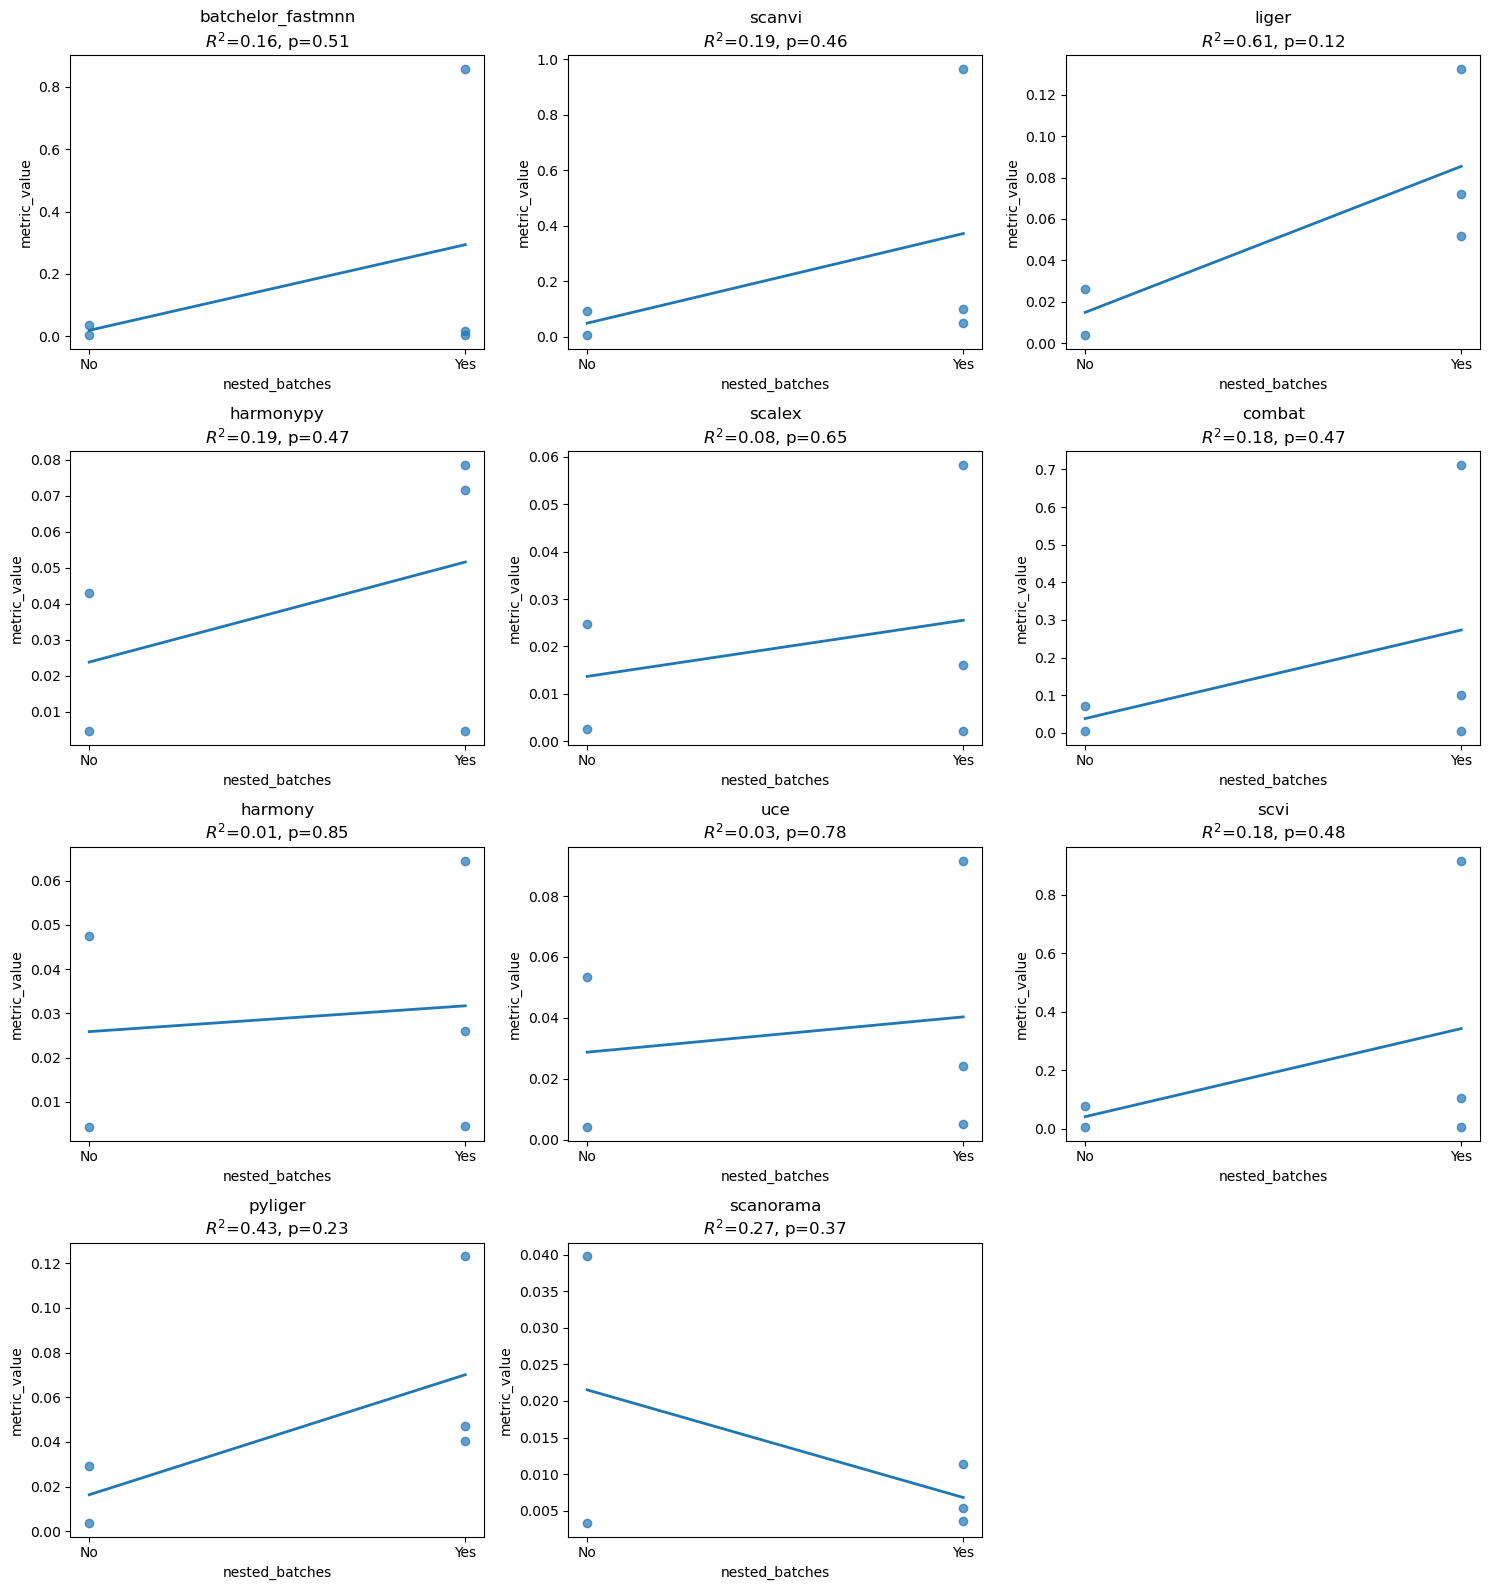

In [58]:
df_metric = df.query("metric_id == 'isolated_label_f1'") 

methods = df.query("control_group == 'non-control method'")["method_id"].unique()

n_methods = len(methods)
ncols = 3                      # change this if you want 2 per row, etc.
nrows = math.ceil(n_methods / ncols)

fig, axes = plt.subplots(nrows, ncols,
                         figsize=(5 * ncols, 4 * nrows),
                         squeeze=False)
axes = axes.ravel()

for ax, method in zip(axes, methods):
    df_m = df_metric.query("method_id == @method")

    res = smf.ols("metric_value ~ nested_batches_num", data=df_m).fit()

    # Scatter points
    x = df_m["nested_batches_num"]
    y = df_m["metric_value"]
    ax.scatter(x, y, alpha=0.7)

    # Regression line
    x_pred = np.linspace(x.min(), x.max(), 100)
    X_pred = pd.DataFrame({"nested_batches_num": x_pred})
    y_pred = res.predict(X_pred)
    ax.plot(x_pred, y_pred, linewidth=2)

    # Labels & title with stats
    ax.set_xticks([0, 1])
    ax.set_xticklabels(["No", "Yes"])
    ax.set_xlabel("nested_batches")
    ax.set_ylabel("metric_value")
    ax.set_title(
        f"{method}\n$R^2$={res.rsquared:.2f}, "
        f"p={res.pvalues['nested_batches_num']:.2g}"
    )

# ------------------------------------------------------------------
# 5) Hide unused axes if grid is larger than number of methods
# ------------------------------------------------------------------
for j in range(n_methods, len(axes)):
    fig.delaxes(axes[j])

# fig.suptitle("metric_value ~ batch_imbalance_gc per method", y=1.02)
fig.tight_layout()
plt.show()

# with isolated_label_asw

In [59]:
rows = []

for method, df_m in df.query("metric_id == 'isolated_label_asw' and control_group == 'non-control method'").groupby("method_id"):
    # skip methods with too few points or no variation
    if df_m["nested_batches_num"].nunique() < 2 or len(df_m) < 4:
        continue

    res = smf.ols("metric_value ~ nested_batches_num", data=df_m).fit()

    rows.append({
        "method_id": method,
        "n": len(df_m),
        "slope": res.params["nested_batches_num"],
        "pval": res.pvalues["nested_batches_num"],
        "r2": res.rsquared,
    })

results = pd.DataFrame(rows)
print(results)

            method_id  n     slope      pval        r2
0   batchelor_fastmnn  5  0.232425  0.206432  0.462574
1              combat  5  0.185235  0.150046  0.552360
2             harmony  5  0.210423  0.136547  0.576495
3           harmonypy  5  0.207849  0.130208  0.588253
4               liger  5  0.134174  0.355636  0.283486
5             pyliger  5  0.153641  0.225396  0.435681
6              scalex  5  0.209077  0.178868  0.504453
7           scanorama  5  0.049317  0.057776  0.749710
8              scanvi  5  0.212769  0.170058  0.518614
9                scvi  5  0.142853  0.183832  0.496647
10                uce  5  0.082738  0.331980  0.307547


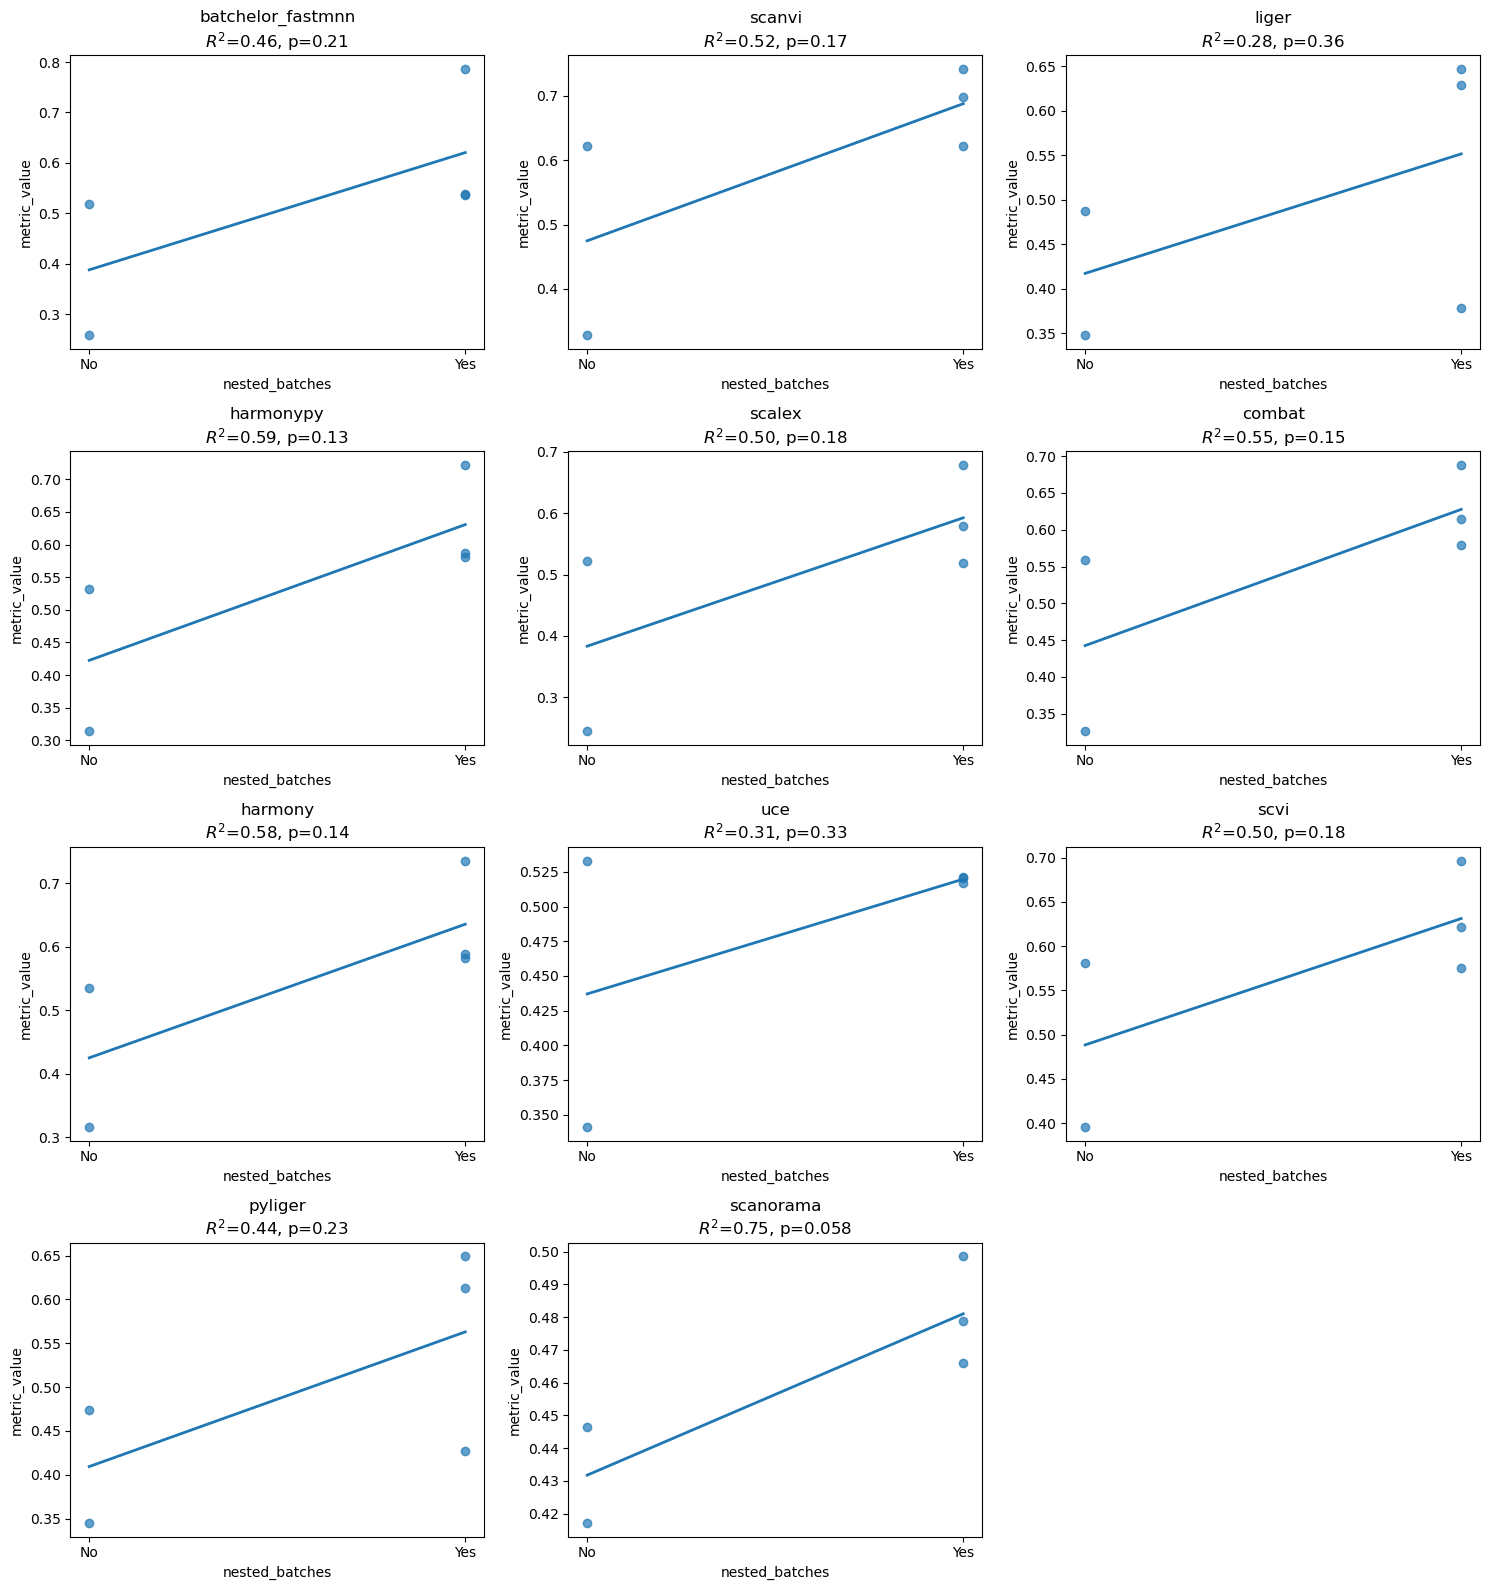

In [61]:
df_metric = df.query("metric_id == 'isolated_label_asw'") 

methods = df.query("control_group == 'non-control method'")["method_id"].unique()

n_methods = len(methods)
ncols = 3                      # change this if you want 2 per row, etc.
nrows = math.ceil(n_methods / ncols)

fig, axes = plt.subplots(nrows, ncols,
                         figsize=(5 * ncols, 4 * nrows),
                         squeeze=False)
axes = axes.ravel()

for ax, method in zip(axes, methods):
    df_m = df_metric.query("method_id == @method")

    res = smf.ols("metric_value ~ nested_batches_num", data=df_m).fit()

    # Scatter points
    x = df_m["nested_batches_num"]
    y = df_m["metric_value"]
    ax.scatter(x, y, alpha=0.7)

    # Regression line
    x_pred = np.linspace(x.min(), x.max(), 100)
    X_pred = pd.DataFrame({"nested_batches_num": x_pred})
    y_pred = res.predict(X_pred)
    ax.plot(x_pred, y_pred, linewidth=2)

    # Labels & title with stats
    ax.set_xticks([0, 1])
    ax.set_xticklabels(["No", "Yes"])
    ax.set_xlabel("nested_batches")
    ax.set_ylabel("metric_value")
    ax.set_title(
        f"{method}\n$R^2$={res.rsquared:.2f}, "
        f"p={res.pvalues['nested_batches_num']:.2g}"
    )

# ------------------------------------------------------------------
# 5) Hide unused axes if grid is larger than number of methods
# ------------------------------------------------------------------
for j in range(n_methods, len(axes)):
    fig.delaxes(axes[j])

# fig.suptitle("metric_value ~ batch_imbalance_gc per method", y=1.02)
fig.tight_layout()
plt.show()

# with pcr

In [62]:
rows = []

for method, df_m in df.query("metric_id == 'pcr' and control_group == 'non-control method'").groupby("method_id"):
    # skip methods with too few points or no variation
    if df_m["nested_batches_num"].nunique() < 2 or len(df_m) < 4:
        continue

    res = smf.ols("metric_value ~ nested_batches_num", data=df_m).fit()

    rows.append({
        "method_id": method,
        "n": len(df_m),
        "slope": res.params["nested_batches_num"],
        "pval": res.pvalues["nested_batches_num"],
        "r2": res.rsquared,
    })

results = pd.DataFrame(rows)
print(results)

            method_id  n     slope      pval        r2
0   batchelor_fastmnn  6 -0.125598  0.454963  0.145869
1              combat  6  0.000195  0.186971  0.387358
2             harmony  6  0.006229  0.939349  0.001637
3           harmonypy  6 -0.007715  0.934275  0.001922
4               liger  6  0.049150  0.723544  0.034769
5             pyliger  6  0.023998  0.818192  0.014837
6              scalex  6 -0.006740  0.362494  0.208639
7           scanorama  6  0.241594  0.499960  0.120636
8              scanvi  6 -0.044900  0.819929  0.014552
9                scvi  6  0.105997  0.494852  0.123345
10                uce  6  0.050092  0.291681  0.269094


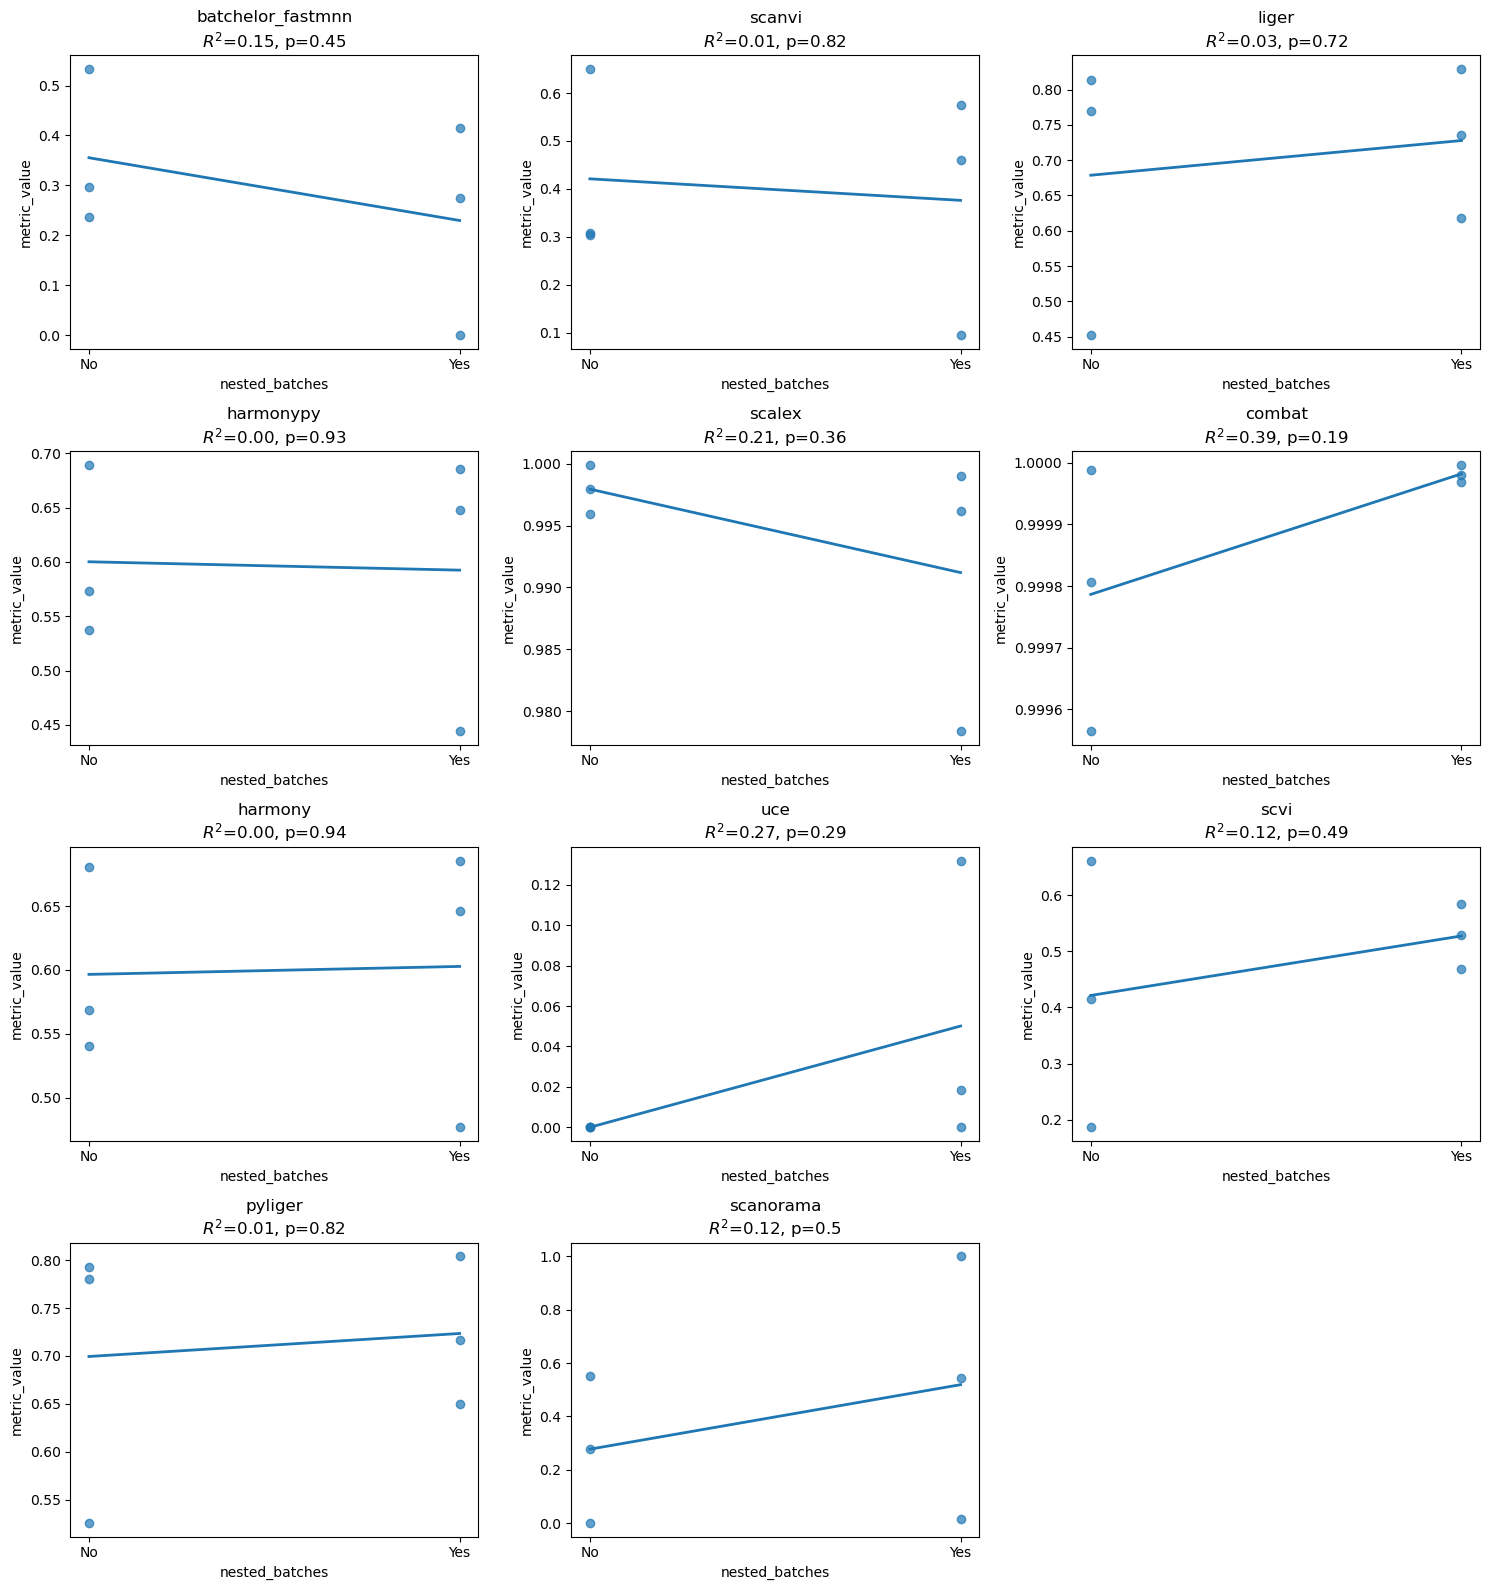

In [63]:
df_metric = df.query("metric_id == 'pcr'") 

methods = df.query("control_group == 'non-control method'")["method_id"].unique()

n_methods = len(methods)
ncols = 3                      # change this if you want 2 per row, etc.
nrows = math.ceil(n_methods / ncols)

fig, axes = plt.subplots(nrows, ncols,
                         figsize=(5 * ncols, 4 * nrows),
                         squeeze=False)
axes = axes.ravel()

for ax, method in zip(axes, methods):
    df_m = df_metric.query("method_id == @method")

    res = smf.ols("metric_value ~ nested_batches_num", data=df_m).fit()

    # Scatter points
    x = df_m["nested_batches_num"]
    y = df_m["metric_value"]
    ax.scatter(x, y, alpha=0.7)

    # Regression line
    x_pred = np.linspace(x.min(), x.max(), 100)
    X_pred = pd.DataFrame({"nested_batches_num": x_pred})
    y_pred = res.predict(X_pred)
    ax.plot(x_pred, y_pred, linewidth=2)

    # Labels & title with stats
    ax.set_xticks([0, 1])
    ax.set_xticklabels(["No", "Yes"])
    ax.set_xlabel("nested_batches")
    ax.set_ylabel("metric_value")
    ax.set_title(
        f"{method}\n$R^2$={res.rsquared:.2f}, "
        f"p={res.pvalues['nested_batches_num']:.2g}"
    )

# ------------------------------------------------------------------
# 5) Hide unused axes if grid is larger than number of methods
# ------------------------------------------------------------------
for j in range(n_methods, len(axes)):
    fig.delaxes(axes[j])

# fig.suptitle("metric_value ~ batch_imbalance_gc per method", y=1.02)
fig.tight_layout()
plt.show()

# with ilisi

In [64]:
rows = []

for method, df_m in df.query("metric_id == 'ilisi' and control_group == 'non-control method'").groupby("method_id"):
    # skip methods with too few points or no variation
    if df_m["nested_batches_num"].nunique() < 2 or len(df_m) < 4:
        continue

    res = smf.ols("metric_value ~ nested_batches_num", data=df_m).fit()

    rows.append({
        "method_id": method,
        "n": len(df_m),
        "slope": res.params["nested_batches_num"],
        "pval": res.pvalues["nested_batches_num"],
        "r2": res.rsquared,
    })

results = pd.DataFrame(rows)
print(results)

            method_id  n     slope      pval        r2
0   batchelor_fastmnn  6 -0.007044  0.941852  0.001504
1              combat  6 -0.029047  0.625125  0.065267
2             harmony  6  0.003937  0.972904  0.000326
3           harmonypy  6 -0.005412  0.962669  0.000620
4               liger  6  0.026052  0.854846  0.009423
5             pyliger  6  0.029145  0.839394  0.011553
6              scalex  6 -0.035073  0.744332  0.029634
7           scanorama  6  0.052457  0.587916  0.079645
8              scanvi  6 -0.028433  0.805656  0.016978
9                scvi  6 -0.043654  0.697588  0.041803
10                uce  6 -0.016764  0.833574  0.012412


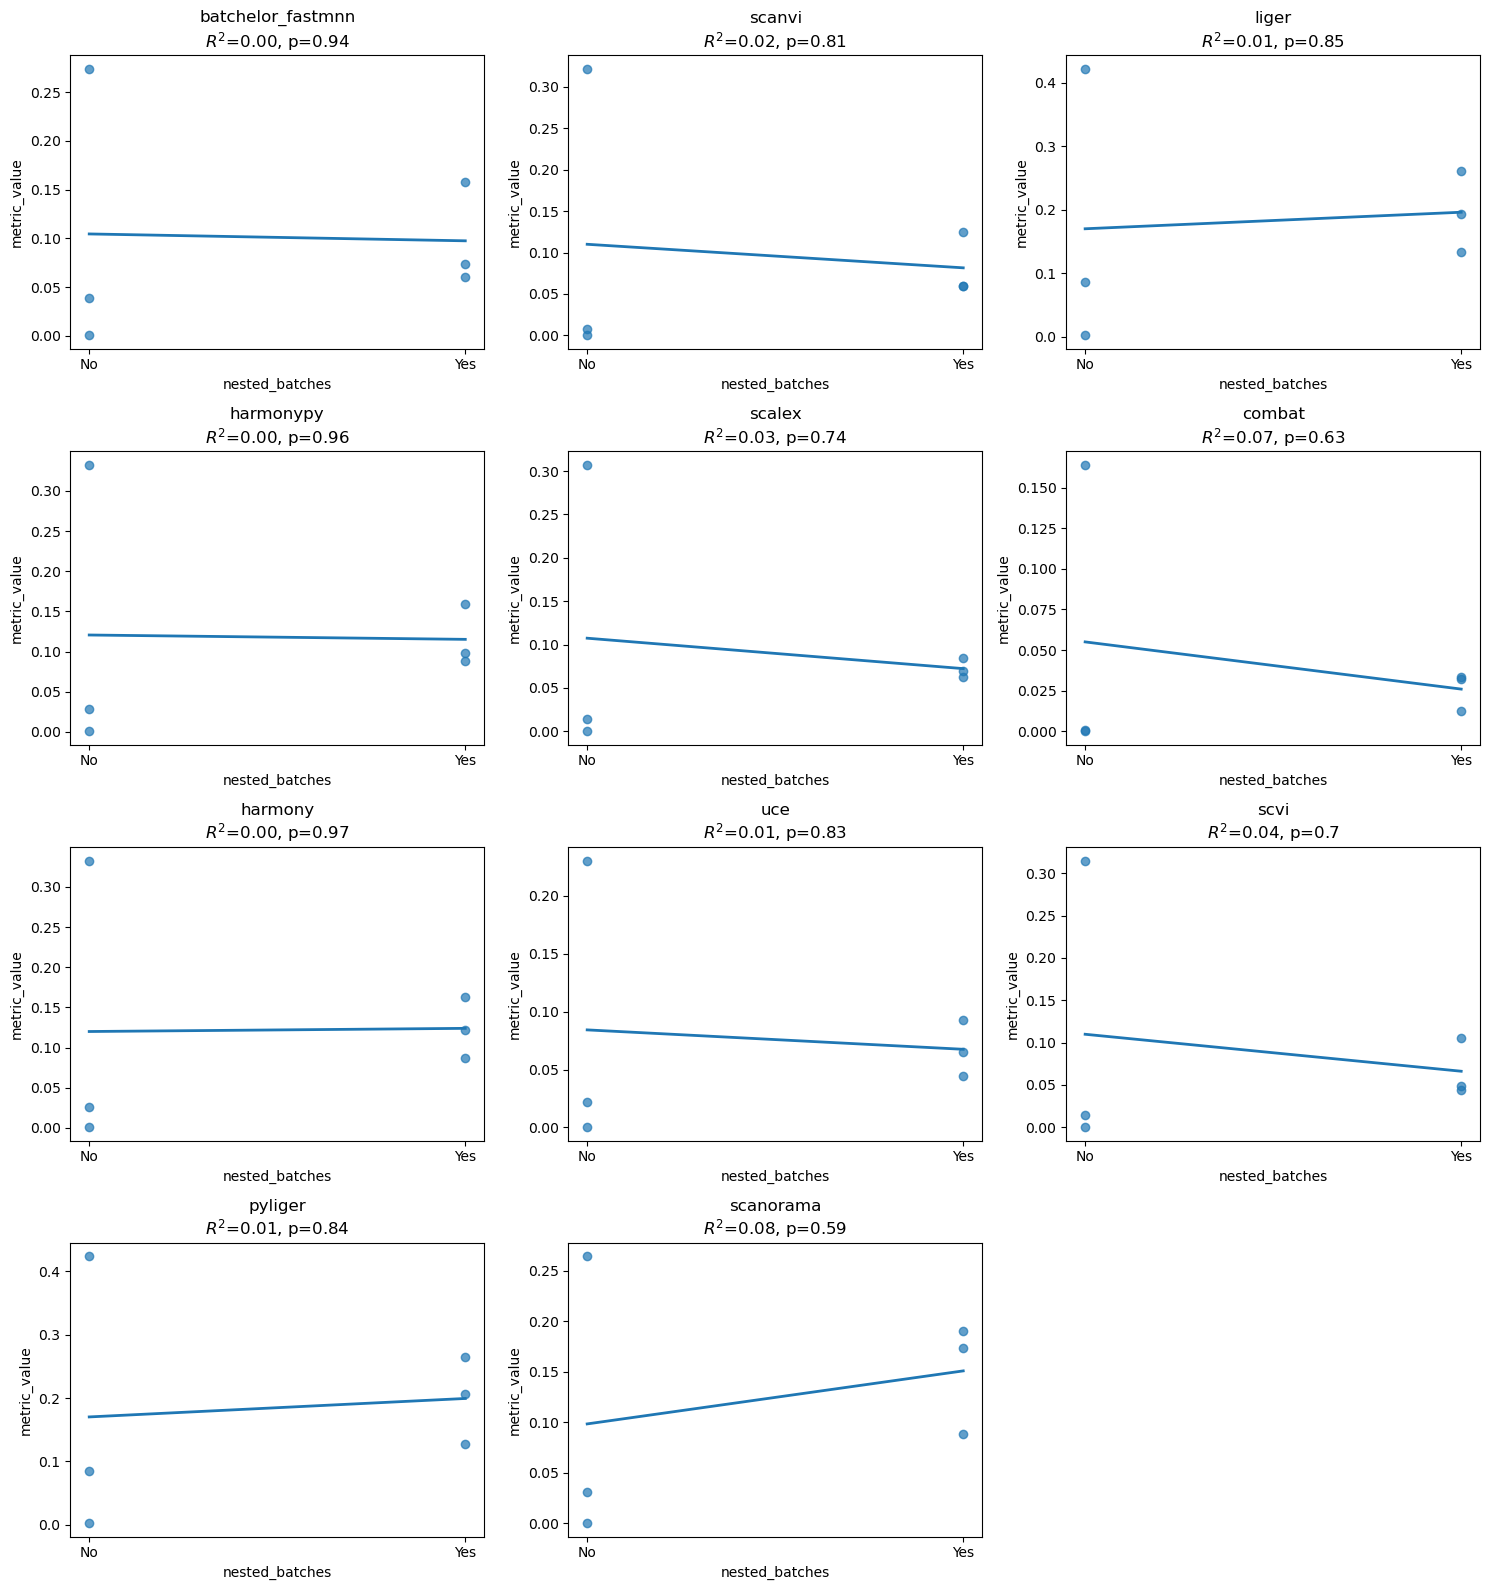

In [65]:
df_metric = df.query("metric_id == 'ilisi'") 

methods = df.query("control_group == 'non-control method'")["method_id"].unique()

n_methods = len(methods)
ncols = 3                      # change this if you want 2 per row, etc.
nrows = math.ceil(n_methods / ncols)

fig, axes = plt.subplots(nrows, ncols,
                         figsize=(5 * ncols, 4 * nrows),
                         squeeze=False)
axes = axes.ravel()

for ax, method in zip(axes, methods):
    df_m = df_metric.query("method_id == @method")

    res = smf.ols("metric_value ~ nested_batches_num", data=df_m).fit()

    # Scatter points
    x = df_m["nested_batches_num"]
    y = df_m["metric_value"]
    ax.scatter(x, y, alpha=0.7)

    # Regression line
    x_pred = np.linspace(x.min(), x.max(), 100)
    X_pred = pd.DataFrame({"nested_batches_num": x_pred})
    y_pred = res.predict(X_pred)
    ax.plot(x_pred, y_pred, linewidth=2)

    # Labels & title with stats
    ax.set_xticks([0, 1])
    ax.set_xticklabels(["No", "Yes"])
    ax.set_xlabel("nested_batches")
    ax.set_ylabel("metric_value")
    ax.set_title(
        f"{method}\n$R^2$={res.rsquared:.2f}, "
        f"p={res.pvalues['nested_batches_num']:.2g}"
    )

# ------------------------------------------------------------------
# 5) Hide unused axes if grid is larger than number of methods
# ------------------------------------------------------------------
for j in range(n_methods, len(axes)):
    fig.delaxes(axes[j])

# fig.suptitle("metric_value ~ batch_imbalance_gc per method", y=1.02)
fig.tight_layout()
plt.show()

# with clisi

In [66]:
rows = []

for method, df_m in df.query("metric_id == 'clisi' and control_group == 'non-control method'").groupby("method_id"):
    # skip methods with too few points or no variation
    if df_m["nested_batches_num"].nunique() < 2 or len(df_m) < 4:
        continue

    res = smf.ols("metric_value ~ nested_batches_num", data=df_m).fit()

    rows.append({
        "method_id": method,
        "n": len(df_m),
        "slope": res.params["nested_batches_num"],
        "pval": res.pvalues["nested_batches_num"],
        "r2": res.rsquared,
    })

results = pd.DataFrame(rows)
print(results)

            method_id  n     slope      pval        r2
0   batchelor_fastmnn  6 -0.001201  0.497523  0.121924
1              combat  6 -0.001667  0.349724  0.218647
2             harmony  6 -0.002931  0.231882  0.331396
3           harmonypy  6 -0.002196  0.356897  0.212981
4               liger  6 -0.010489  0.025382  0.751571
5             pyliger  6 -0.009107  0.093359  0.545975
6              scalex  6 -0.010384  0.099557  0.532798
7           scanorama  6 -0.101934  0.202863  0.366483
8              scanvi  6 -0.000062  0.577834  0.083830
9                scvi  6 -0.000771  0.485180  0.128581
10                uce  6 -0.002592  0.362927  0.208306


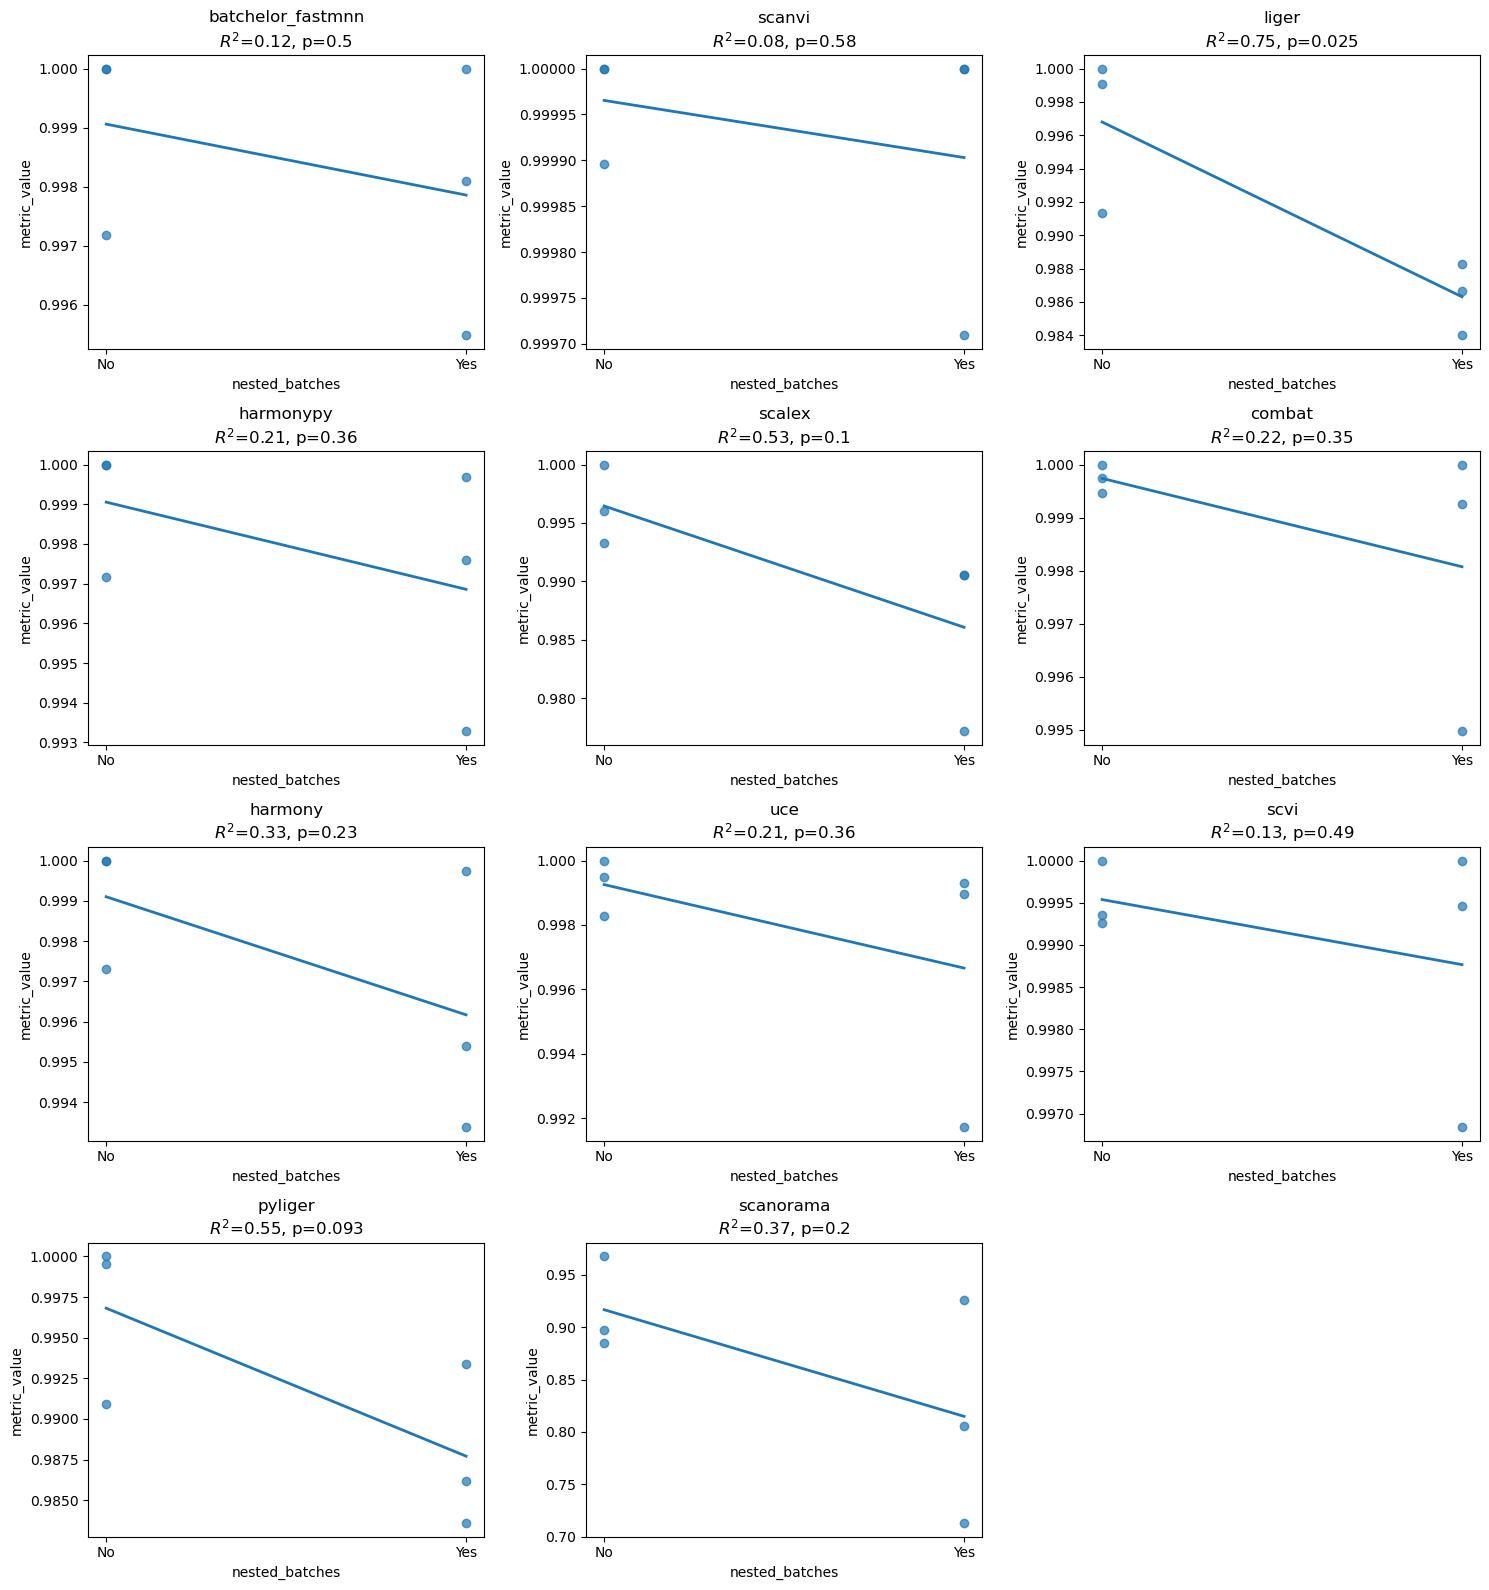

In [67]:
df_metric = df.query("metric_id == 'clisi'") 

methods = df.query("control_group == 'non-control method'")["method_id"].unique()

n_methods = len(methods)
ncols = 3                      # change this if you want 2 per row, etc.
nrows = math.ceil(n_methods / ncols)

fig, axes = plt.subplots(nrows, ncols,
                         figsize=(5 * ncols, 4 * nrows),
                         squeeze=False)
axes = axes.ravel()

for ax, method in zip(axes, methods):
    df_m = df_metric.query("method_id == @method")

    res = smf.ols("metric_value ~ nested_batches_num", data=df_m).fit()

    # Scatter points
    x = df_m["nested_batches_num"]
    y = df_m["metric_value"]
    ax.scatter(x, y, alpha=0.7)

    # Regression line
    x_pred = np.linspace(x.min(), x.max(), 100)
    X_pred = pd.DataFrame({"nested_batches_num": x_pred})
    y_pred = res.predict(X_pred)
    ax.plot(x_pred, y_pred, linewidth=2)

    # Labels & title with stats
    ax.set_xticks([0, 1])
    ax.set_xticklabels(["No", "Yes"])
    ax.set_xlabel("nested_batches")
    ax.set_ylabel("metric_value")
    ax.set_title(
        f"{method}\n$R^2$={res.rsquared:.2f}, "
        f"p={res.pvalues['nested_batches_num']:.2g}"
    )

# ------------------------------------------------------------------
# 5) Hide unused axes if grid is larger than number of methods
# ------------------------------------------------------------------
for j in range(n_methods, len(axes)):
    fig.delaxes(axes[j])

# fig.suptitle("metric_value ~ batch_imbalance_gc per method", y=1.02)
fig.tight_layout()
plt.show()

# with asw_batch

In [68]:
rows = []

for method, df_m in df.query("metric_id == 'asw_batch' and control_group == 'non-control method'").groupby("method_id"):
    # skip methods with too few points or no variation
    if df_m["nested_batches_num"].nunique() < 2 or len(df_m) < 4:
        continue

    res = smf.ols("metric_value ~ nested_batches_num", data=df_m).fit()

    rows.append({
        "method_id": method,
        "n": len(df_m),
        "slope": res.params["nested_batches_num"],
        "pval": res.pvalues["nested_batches_num"],
        "r2": res.rsquared,
    })

results = pd.DataFrame(rows)
print(results)

            method_id  n     slope      pval        r2
0   batchelor_fastmnn  6  0.020373  0.383928  0.192630
1              combat  6  0.028965  0.474872  0.134318
2             harmony  6  0.023055  0.601501  0.074204
3           harmonypy  6  0.026051  0.553681  0.094378
4               liger  6 -0.024176  0.753231  0.027569
5             pyliger  6 -0.000858  0.991355  0.000033
6              scalex  6  0.012768  0.651896  0.055921
7           scanorama  6  0.013828  0.810240  0.016178
8              scanvi  6  0.026431  0.481275  0.130735
9                scvi  6  0.033561  0.304592  0.257113
10                uce  6  0.023514  0.041691  0.686080


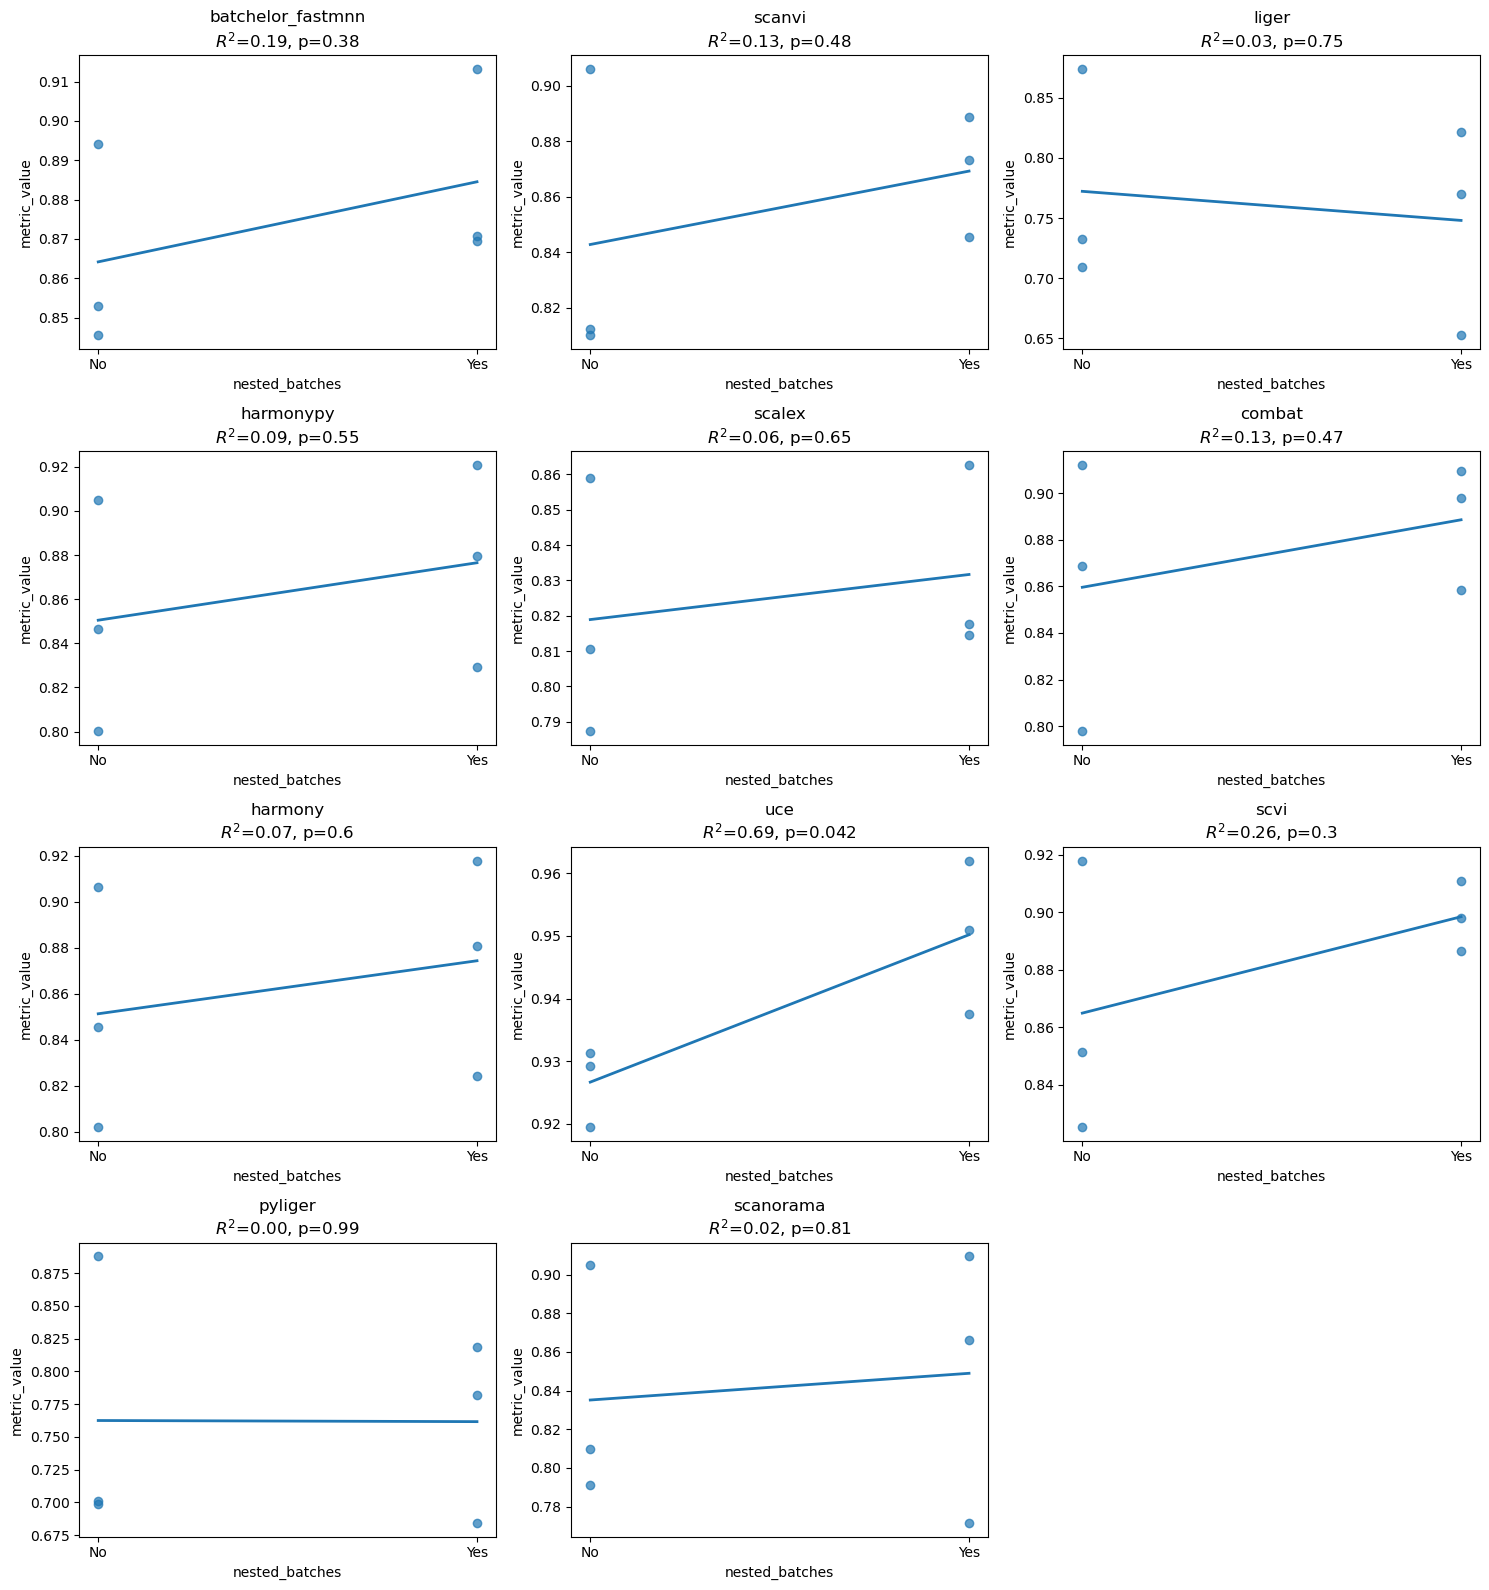

In [69]:
df_metric = df.query("metric_id == 'asw_batch'") 

methods = df.query("control_group == 'non-control method'")["method_id"].unique()

n_methods = len(methods)
ncols = 3                      # change this if you want 2 per row, etc.
nrows = math.ceil(n_methods / ncols)

fig, axes = plt.subplots(nrows, ncols,
                         figsize=(5 * ncols, 4 * nrows),
                         squeeze=False)
axes = axes.ravel()

for ax, method in zip(axes, methods):
    df_m = df_metric.query("method_id == @method")

    res = smf.ols("metric_value ~ nested_batches_num", data=df_m).fit()

    # Scatter points
    x = df_m["nested_batches_num"]
    y = df_m["metric_value"]
    ax.scatter(x, y, alpha=0.7)

    # Regression line
    x_pred = np.linspace(x.min(), x.max(), 100)
    X_pred = pd.DataFrame({"nested_batches_num": x_pred})
    y_pred = res.predict(X_pred)
    ax.plot(x_pred, y_pred, linewidth=2)

    # Labels & title with stats
    ax.set_xticks([0, 1])
    ax.set_xticklabels(["No", "Yes"])
    ax.set_xlabel("nested_batches")
    ax.set_ylabel("metric_value")
    ax.set_title(
        f"{method}\n$R^2$={res.rsquared:.2f}, "
        f"p={res.pvalues['nested_batches_num']:.2g}"
    )

# ------------------------------------------------------------------
# 5) Hide unused axes if grid is larger than number of methods
# ------------------------------------------------------------------
for j in range(n_methods, len(axes)):
    fig.delaxes(axes[j])

# fig.suptitle("metric_value ~ batch_imbalance_gc per method", y=1.02)
fig.tight_layout()
plt.show()

# with kbet_pg

In [70]:
rows = []

for method, df_m in df.query("metric_id == 'kbet_pg' and control_group == 'non-control method'").groupby("method_id"):
    # skip methods with too few points or no variation
    if df_m["nested_batches_num"].nunique() < 2 or len(df_m) < 4:
        continue

    res = smf.ols("metric_value ~ nested_batches_num", data=df_m).fit()

    rows.append({
        "method_id": method,
        "n": len(df_m),
        "slope": res.params["nested_batches_num"],
        "pval": res.pvalues["nested_batches_num"],
        "r2": res.rsquared,
    })

results = pd.DataFrame(rows)
print(results)

            method_id  n     slope      pval        r2
0   batchelor_fastmnn  6 -0.304442  0.334768  0.230839
1              combat  6 -0.305583  0.371654  0.201680
2             harmony  6 -0.291077  0.336345  0.229529
3           harmonypy  6 -0.292907  0.333688  0.231741
4               liger  6 -0.336946  0.149453  0.442363
5             pyliger  6 -0.353983  0.130447  0.474013
6              scalex  6 -0.315131  0.342277  0.224653
7           scanorama  6  0.009615  0.982664  0.000134
8              scanvi  6 -0.292786  0.347461  0.220458
9                scvi  6 -0.302780  0.336944  0.229033
10                uce  6 -0.302142  0.352300  0.216599


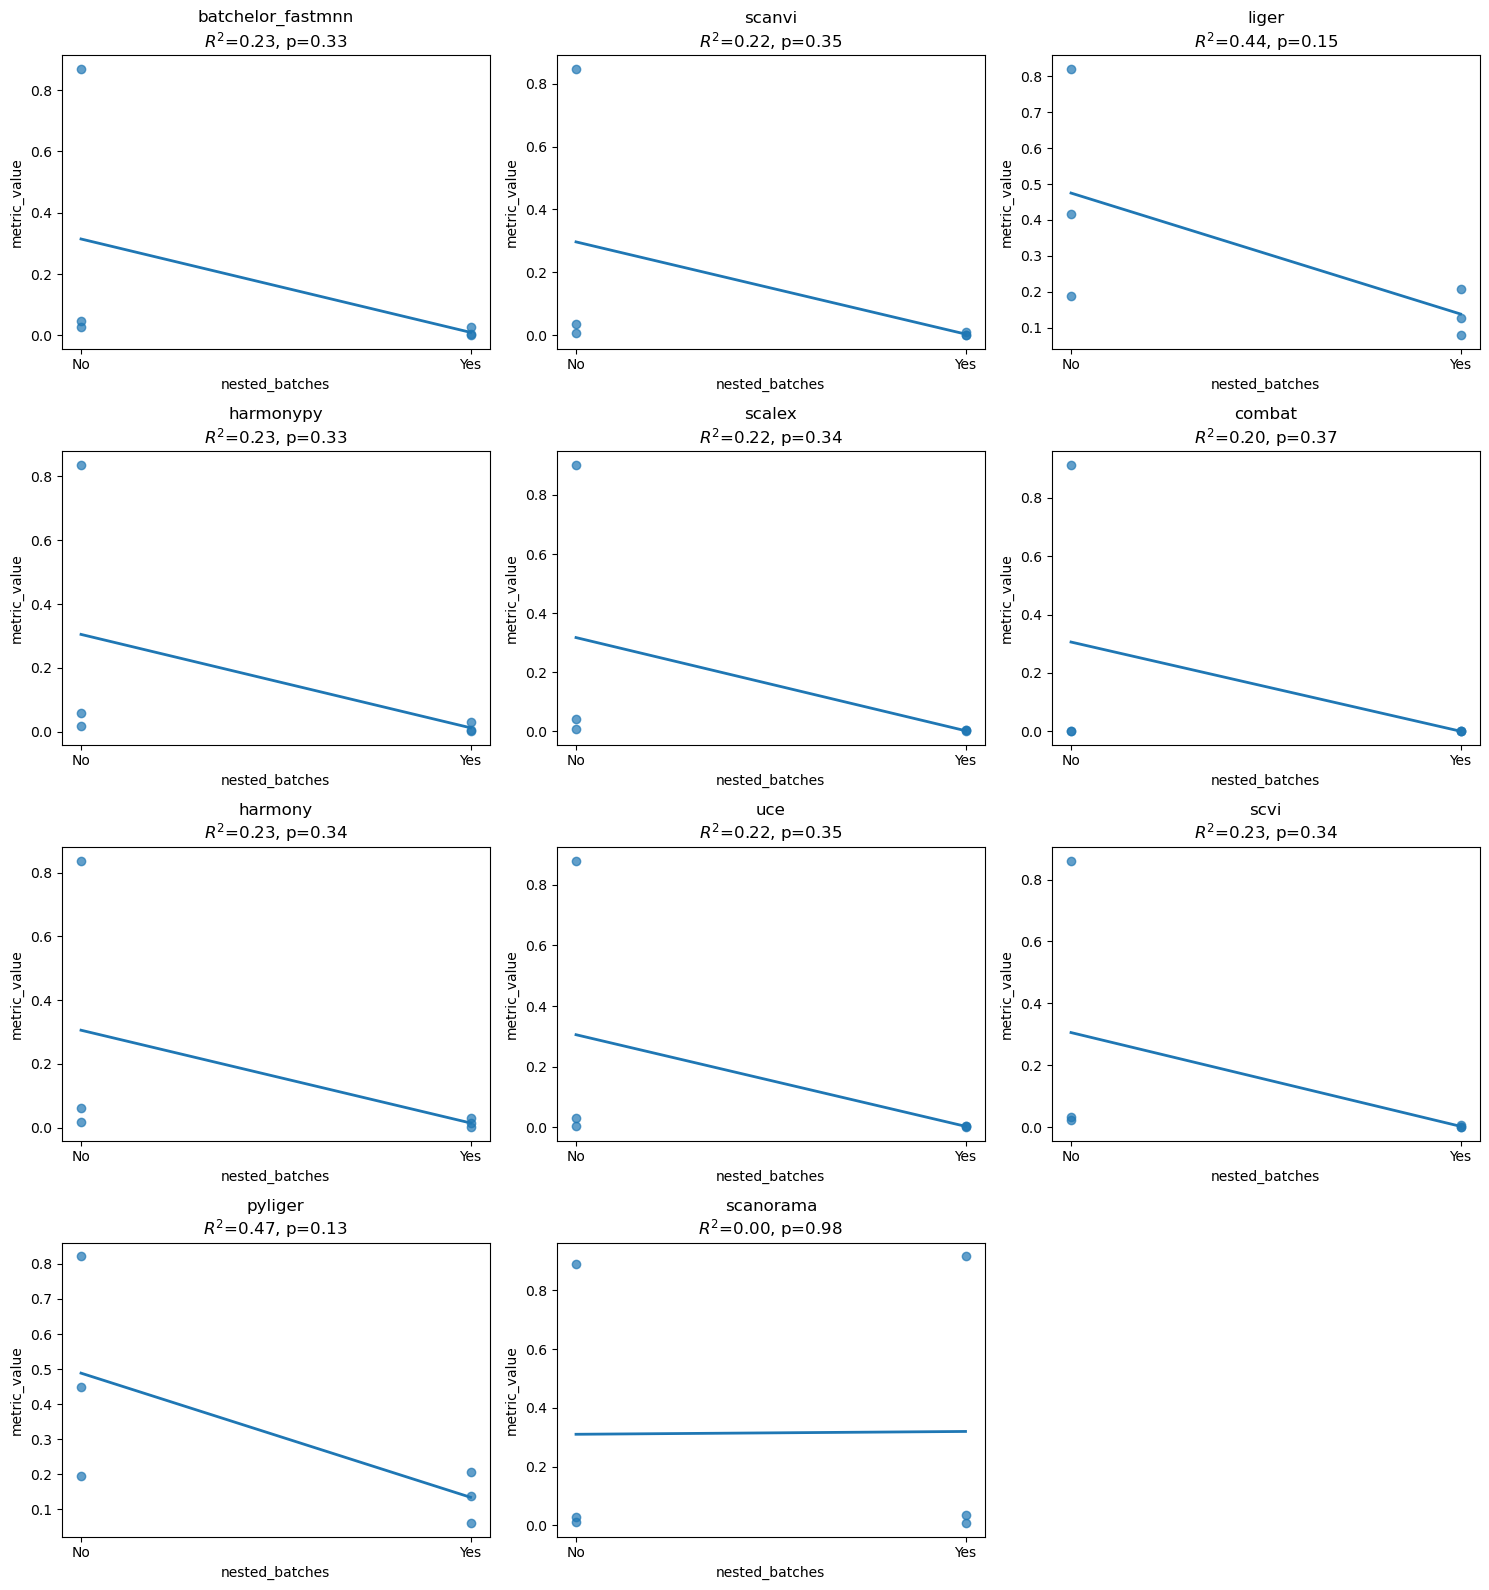

In [71]:
df_metric = df.query("metric_id == 'kbet_pg'") 

methods = df.query("control_group == 'non-control method'")["method_id"].unique()

n_methods = len(methods)
ncols = 3                      # change this if you want 2 per row, etc.
nrows = math.ceil(n_methods / ncols)

fig, axes = plt.subplots(nrows, ncols,
                         figsize=(5 * ncols, 4 * nrows),
                         squeeze=False)
axes = axes.ravel()

for ax, method in zip(axes, methods):
    df_m = df_metric.query("method_id == @method")

    res = smf.ols("metric_value ~ nested_batches_num", data=df_m).fit()

    # Scatter points
    x = df_m["nested_batches_num"]
    y = df_m["metric_value"]
    ax.scatter(x, y, alpha=0.7)

    # Regression line
    x_pred = np.linspace(x.min(), x.max(), 100)
    X_pred = pd.DataFrame({"nested_batches_num": x_pred})
    y_pred = res.predict(X_pred)
    ax.plot(x_pred, y_pred, linewidth=2)

    # Labels & title with stats
    ax.set_xticks([0, 1])
    ax.set_xticklabels(["No", "Yes"])
    ax.set_xlabel("nested_batches")
    ax.set_ylabel("metric_value")
    ax.set_title(
        f"{method}\n$R^2$={res.rsquared:.2f}, "
        f"p={res.pvalues['nested_batches_num']:.2g}"
    )

# ------------------------------------------------------------------
# 5) Hide unused axes if grid is larger than number of methods
# ------------------------------------------------------------------
for j in range(n_methods, len(axes)):
    fig.delaxes(axes[j])

# fig.suptitle("metric_value ~ batch_imbalance_gc per method", y=1.02)
fig.tight_layout()
plt.show()

# with kbet_pg_label

In [72]:
rows = []

for method, df_m in df.query("metric_id == 'kbet_pg_label' and control_group == 'non-control method'").groupby("method_id"):
    # skip methods with too few points or no variation
    if df_m["nested_batches_num"].nunique() < 2 or len(df_m) < 4:
        continue

    res = smf.ols("metric_value ~ nested_batches_num", data=df_m).fit()

    rows.append({
        "method_id": method,
        "n": len(df_m),
        "slope": res.params["nested_batches_num"],
        "pval": res.pvalues["nested_batches_num"],
        "r2": res.rsquared,
    })

results = pd.DataFrame(rows)
print(results)

            method_id  n     slope      pval        r2
0   batchelor_fastmnn  6 -0.233190  0.221822  0.343150
1              combat  6 -0.315762  0.272331  0.287963
2             harmony  6 -0.244225  0.203676  0.365449
3           harmonypy  6 -0.244122  0.193146  0.379094
4               liger  6 -0.213036  0.178318  0.399284
5             pyliger  6 -0.244393  0.131828  0.471611
6              scalex  6 -0.328719  0.202305  0.367195
7           scanorama  6  0.014533  0.964405  0.000563
8              scanvi  6 -0.241702  0.289216  0.271435
9                scvi  6 -0.275106  0.248078  0.313306
10                uce  6 -0.235816  0.376262  0.198246


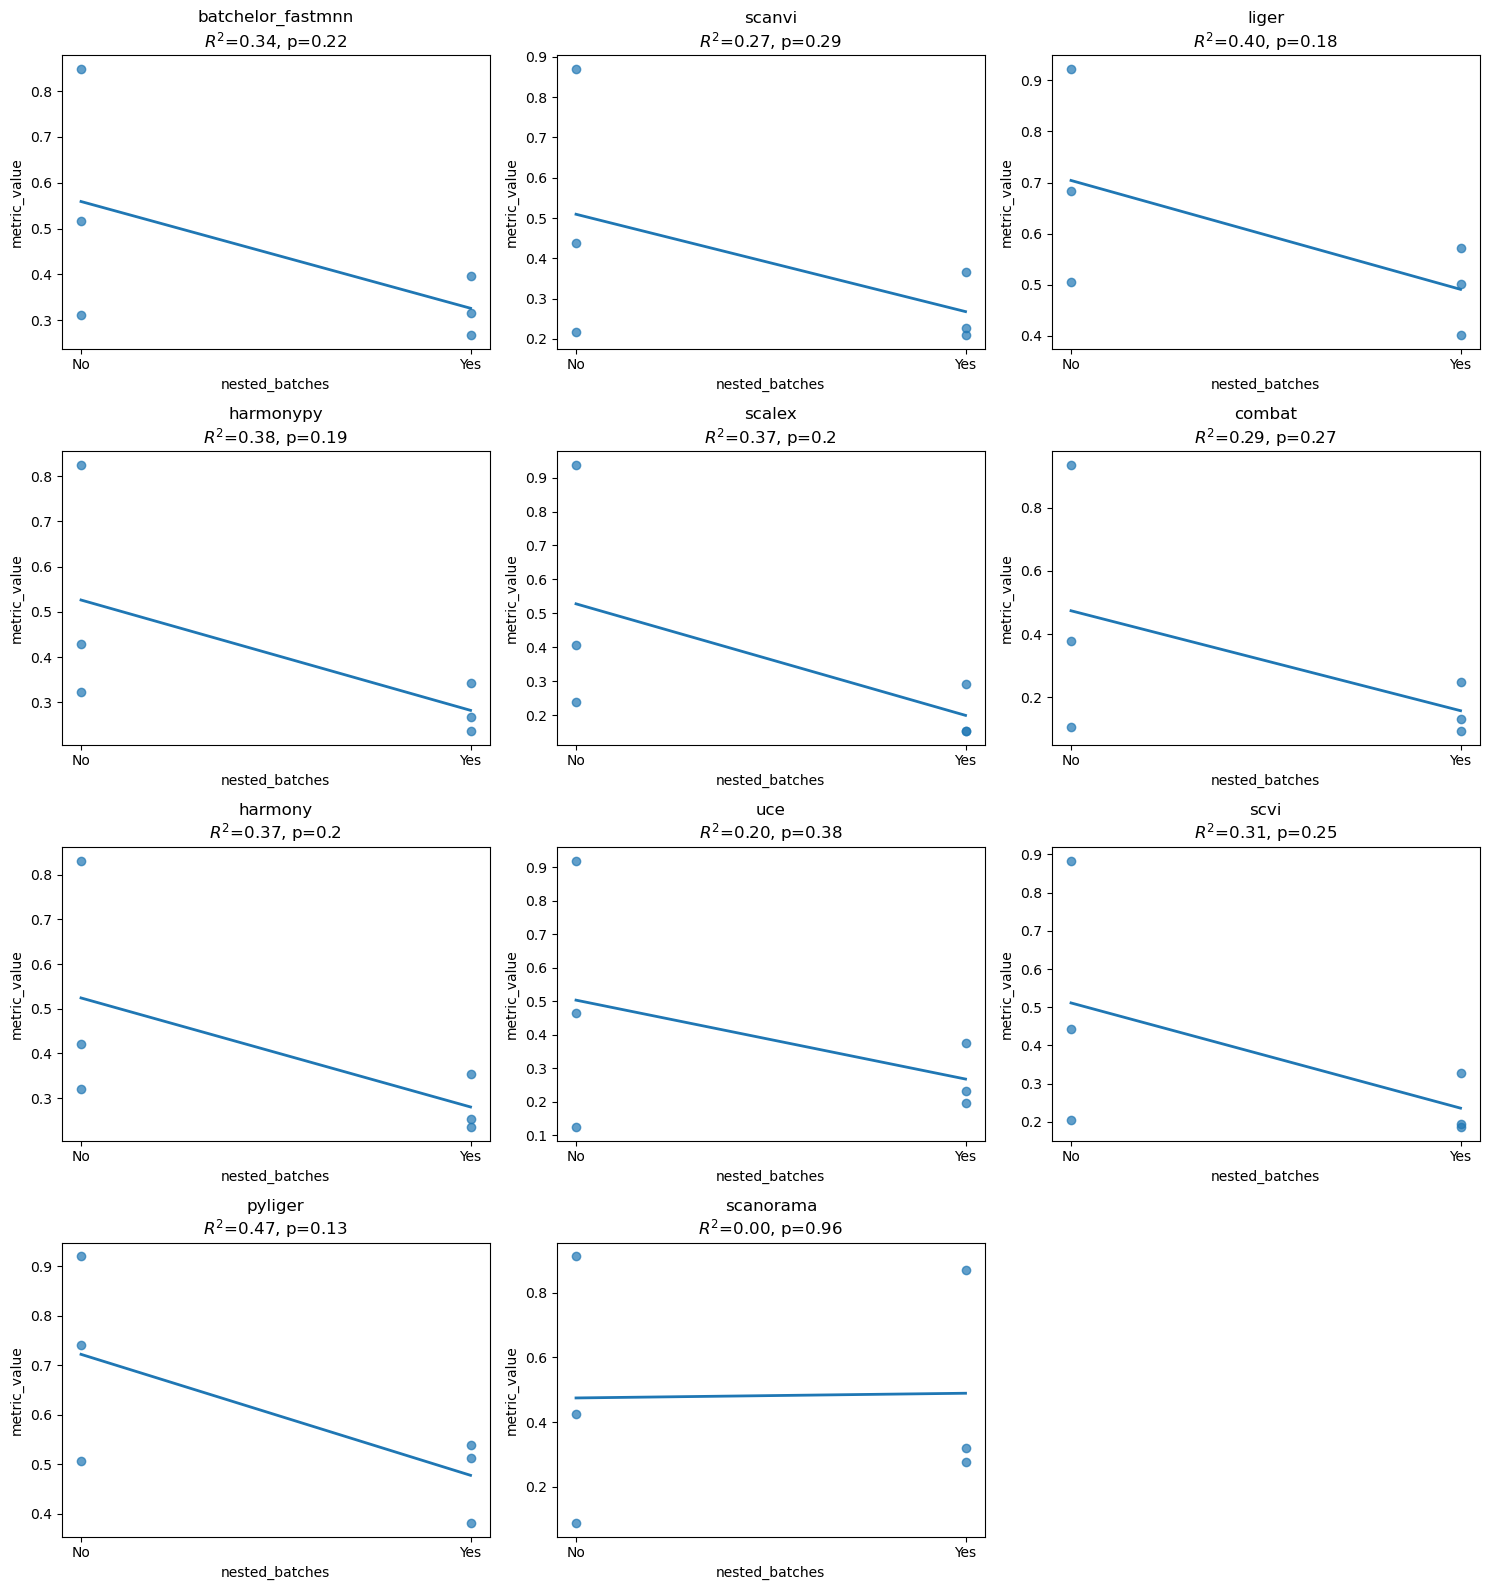

In [73]:
df_metric = df.query("metric_id == 'kbet_pg_label'") 

methods = df.query("control_group == 'non-control method'")["method_id"].unique()

n_methods = len(methods)
ncols = 3                      # change this if you want 2 per row, etc.
nrows = math.ceil(n_methods / ncols)

fig, axes = plt.subplots(nrows, ncols,
                         figsize=(5 * ncols, 4 * nrows),
                         squeeze=False)
axes = axes.ravel()

for ax, method in zip(axes, methods):
    df_m = df_metric.query("method_id == @method")

    res = smf.ols("metric_value ~ nested_batches_num", data=df_m).fit()

    # Scatter points
    x = df_m["nested_batches_num"]
    y = df_m["metric_value"]
    ax.scatter(x, y, alpha=0.7)

    # Regression line
    x_pred = np.linspace(x.min(), x.max(), 100)
    X_pred = pd.DataFrame({"nested_batches_num": x_pred})
    y_pred = res.predict(X_pred)
    ax.plot(x_pred, y_pred, linewidth=2)

    # Labels & title with stats
    ax.set_xticks([0, 1])
    ax.set_xticklabels(["No", "Yes"])
    ax.set_xlabel("nested_batches")
    ax.set_ylabel("metric_value")
    ax.set_title(
        f"{method}\n$R^2$={res.rsquared:.2f}, "
        f"p={res.pvalues['nested_batches_num']:.2g}"
    )

# ------------------------------------------------------------------
# 5) Hide unused axes if grid is larger than number of methods
# ------------------------------------------------------------------
for j in range(n_methods, len(axes)):
    fig.delaxes(axes[j])

# fig.suptitle("metric_value ~ batch_imbalance_gc per method", y=1.02)
fig.tight_layout()
plt.show()

# with ari_batch

In [74]:
rows = []

for method, df_m in df.query("metric_id == 'ari_batch' and control_group == 'non-control method'").groupby("method_id"):
    # skip methods with too few points or no variation
    if df_m["nested_batches_num"].nunique() < 2 or len(df_m) < 4:
        continue

    res = smf.ols("metric_value ~ nested_batches_num", data=df_m).fit()

    rows.append({
        "method_id": method,
        "n": len(df_m),
        "slope": res.params["nested_batches_num"],
        "pval": res.pvalues["nested_batches_num"],
        "r2": res.rsquared,
    })

results = pd.DataFrame(rows)
print(results)

            method_id  n     slope      pval        r2
0   batchelor_fastmnn  6 -0.054839  0.138816  0.459713
1              combat  6 -0.037911  0.335063  0.230594
2             harmony  6 -0.020053  0.383647  0.192833
3           harmonypy  6 -0.028885  0.286245  0.274281
4               liger  6 -0.005810  0.737923  0.031171
5             pyliger  6 -0.007814  0.599626  0.074942
6              scalex  6 -0.012288  0.423382  0.165537
7           scanorama  6 -0.014320  0.655075  0.054865
8              scanvi  6 -0.037006  0.273228  0.287063
9                scvi  6 -0.039188  0.224299  0.340218
10                uce  6 -0.024911  0.567427  0.088284


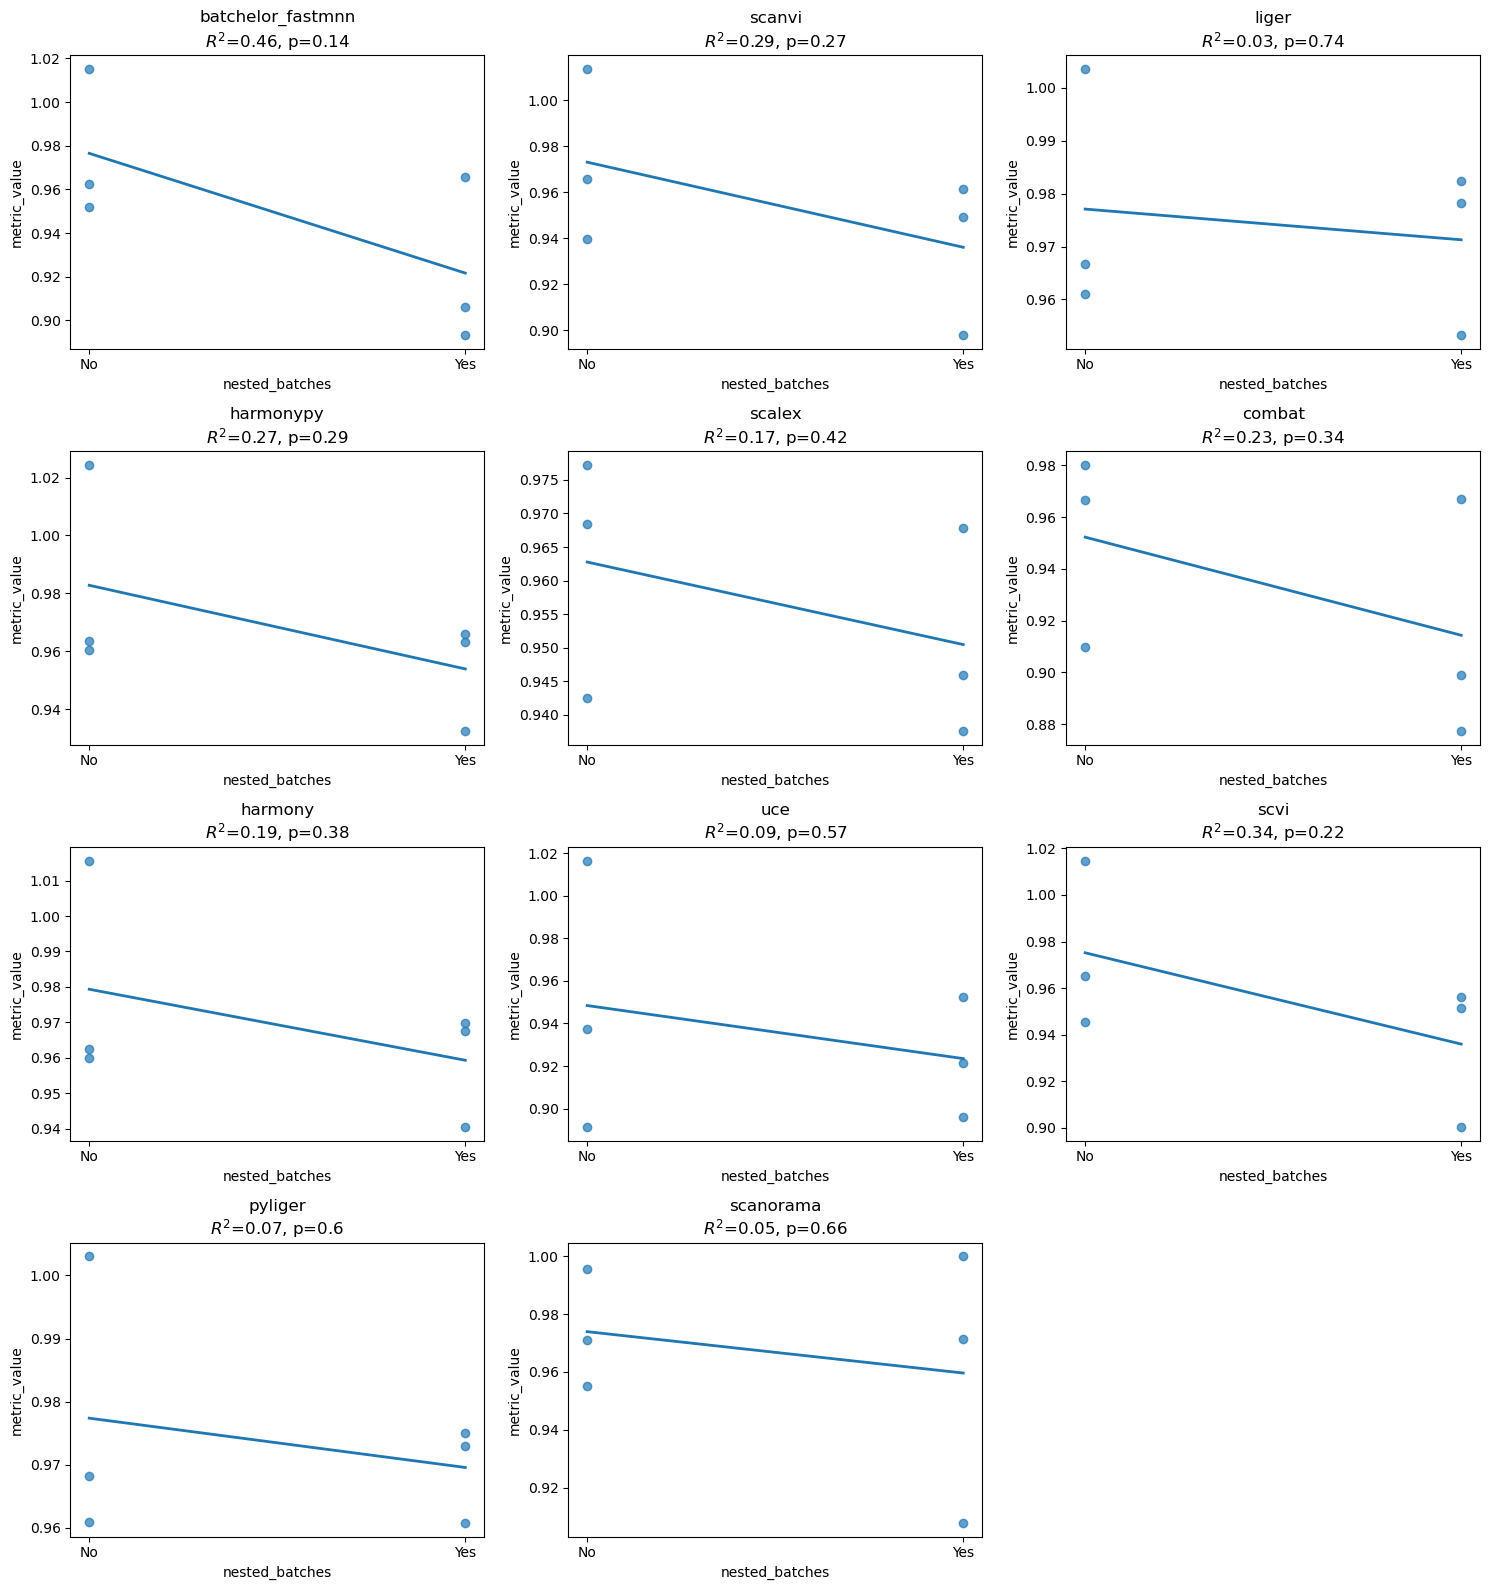

In [75]:
df_metric = df.query("metric_id == 'ari_batch'") 

methods = df.query("control_group == 'non-control method'")["method_id"].unique()

n_methods = len(methods)
ncols = 3                      # change this if you want 2 per row, etc.
nrows = math.ceil(n_methods / ncols)

fig, axes = plt.subplots(nrows, ncols,
                         figsize=(5 * ncols, 4 * nrows),
                         squeeze=False)
axes = axes.ravel()

for ax, method in zip(axes, methods):
    df_m = df_metric.query("method_id == @method")

    res = smf.ols("metric_value ~ nested_batches_num", data=df_m).fit()

    # Scatter points
    x = df_m["nested_batches_num"]
    y = df_m["metric_value"]
    ax.scatter(x, y, alpha=0.7)

    # Regression line
    x_pred = np.linspace(x.min(), x.max(), 100)
    X_pred = pd.DataFrame({"nested_batches_num": x_pred})
    y_pred = res.predict(X_pred)
    ax.plot(x_pred, y_pred, linewidth=2)

    # Labels & title with stats
    ax.set_xticks([0, 1])
    ax.set_xticklabels(["No", "Yes"])
    ax.set_xlabel("nested_batches")
    ax.set_ylabel("metric_value")
    ax.set_title(
        f"{method}\n$R^2$={res.rsquared:.2f}, "
        f"p={res.pvalues['nested_batches_num']:.2g}"
    )

# ------------------------------------------------------------------
# 5) Hide unused axes if grid is larger than number of methods
# ------------------------------------------------------------------
for j in range(n_methods, len(axes)):
    fig.delaxes(axes[j])

# fig.suptitle("metric_value ~ batch_imbalance_gc per method", y=1.02)
fig.tight_layout()
plt.show()

# with nmi_batch

In [76]:
rows = []

for method, df_m in df.query("metric_id == 'nmi_batch' and control_group == 'non-control method'").groupby("method_id"):
    # skip methods with too few points or no variation
    if df_m["nested_batches_num"].nunique() < 2 or len(df_m) < 4:
        continue

    res = smf.ols("metric_value ~ nested_batches_num", data=df_m).fit()

    rows.append({
        "method_id": method,
        "n": len(df_m),
        "slope": res.params["nested_batches_num"],
        "pval": res.pvalues["nested_batches_num"],
        "r2": res.rsquared,
    })

results = pd.DataFrame(rows)
print(results)

            method_id  n     slope      pval        r2
0   batchelor_fastmnn  6 -0.110026  0.310408  0.251865
1              combat  6 -0.084844  0.568661  0.087748
2             harmony  6 -0.062543  0.371864  0.201523
3           harmonypy  6 -0.074576  0.310699  0.251605
4               liger  6 -0.049791  0.271273  0.289028
5             pyliger  6 -0.050833  0.288732  0.271898
6              scalex  6 -0.050677  0.543878  0.098876
7           scanorama  6  0.007586  0.948577  0.001176
8              scanvi  6 -0.075884  0.549551  0.096257
9                scvi  6 -0.100533  0.354443  0.214906
10                uce  6 -0.071549  0.508928  0.115972


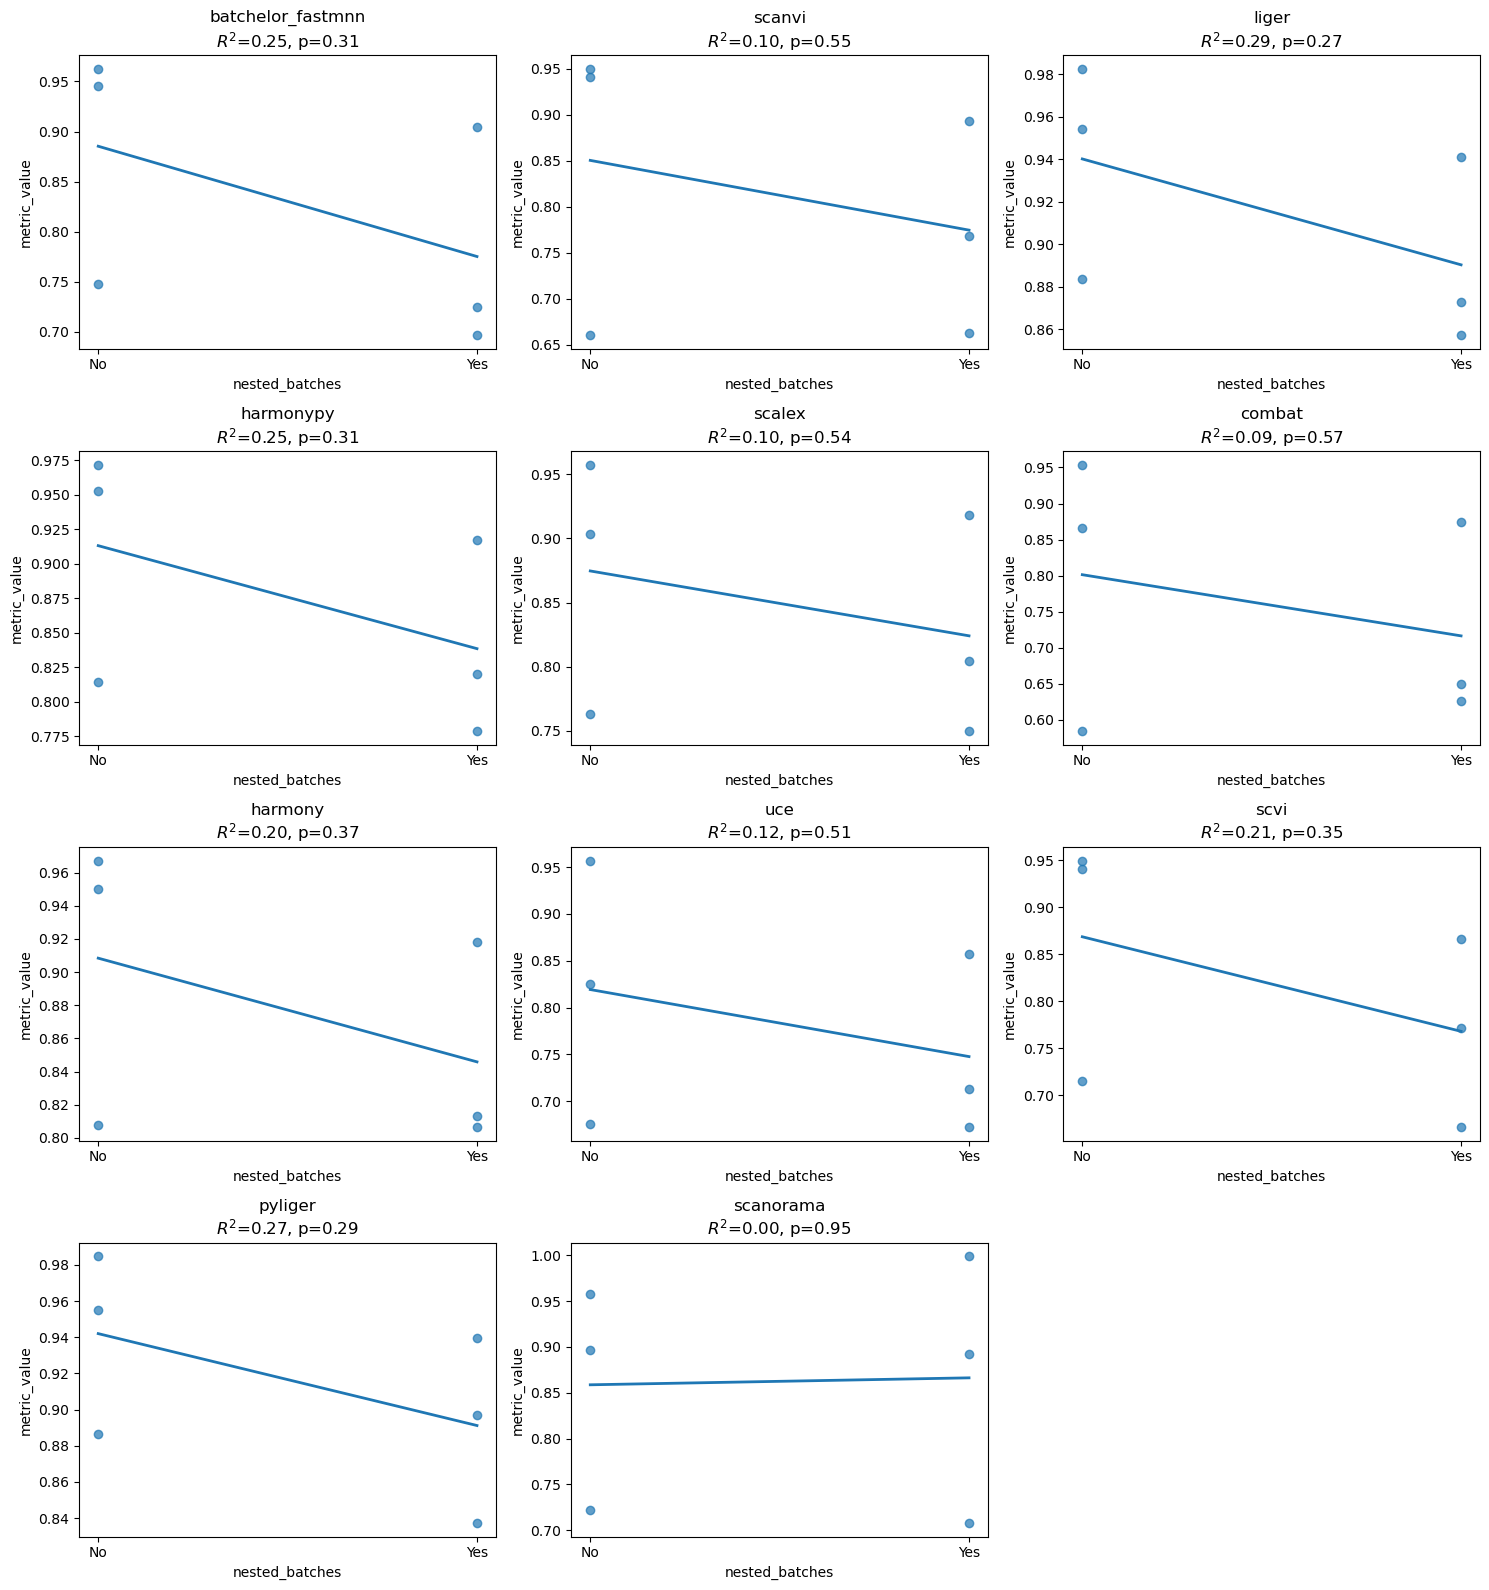

In [77]:
df_metric = df.query("metric_id == 'nmi_batch'") 

methods = df.query("control_group == 'non-control method'")["method_id"].unique()

n_methods = len(methods)
ncols = 3                      # change this if you want 2 per row, etc.
nrows = math.ceil(n_methods / ncols)

fig, axes = plt.subplots(nrows, ncols,
                         figsize=(5 * ncols, 4 * nrows),
                         squeeze=False)
axes = axes.ravel()

for ax, method in zip(axes, methods):
    df_m = df_metric.query("method_id == @method")

    res = smf.ols("metric_value ~ nested_batches_num", data=df_m).fit()

    # Scatter points
    x = df_m["nested_batches_num"]
    y = df_m["metric_value"]
    ax.scatter(x, y, alpha=0.7)

    # Regression line
    x_pred = np.linspace(x.min(), x.max(), 100)
    X_pred = pd.DataFrame({"nested_batches_num": x_pred})
    y_pred = res.predict(X_pred)
    ax.plot(x_pred, y_pred, linewidth=2)

    # Labels & title with stats
    ax.set_xticks([0, 1])
    ax.set_xticklabels(["No", "Yes"])
    ax.set_xlabel("nested_batches")
    ax.set_ylabel("metric_value")
    ax.set_title(
        f"{method}\n$R^2$={res.rsquared:.2f}, "
        f"p={res.pvalues['nested_batches_num']:.2g}"
    )

# ------------------------------------------------------------------
# 5) Hide unused axes if grid is larger than number of methods
# ------------------------------------------------------------------
for j in range(n_methods, len(axes)):
    fig.delaxes(axes[j])

# fig.suptitle("metric_value ~ batch_imbalance_gc per method", y=1.02)
fig.tight_layout()
plt.show()